# Thesis 07: Final Experiment

Load the final experiment run artifacts, posthoc external ID/OOD evaluations, and create thesis-ready result tables. The posthoc metrics are the primary external evaluation source.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display


def _find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "src").is_dir():
            if str(candidate) not in sys.path:
                sys.path.insert(0, str(candidate))
            return candidate
    raise FileNotFoundError(f"Could not find repository root from {cwd}")


REPO = _find_repo_root()

from src.visualization.results_helpers import (  # noqa: E402
    aggregate_mean_sem,
    load_json,
    load_posthoc_external_eval,
    mean_sem_text,
)
from results.notebook_utils import table_dir, write_table, write_numeric_table  # noqa: E402
from src.visualization.thesis_style import set_thesis_style  # noqa: E402
from src.experiments.pipeline.helpers.posthoc_evaluation import resolve_posthoc_path  # noqa: E402

ROOT = REPO / "outputs" / "final_experiment"
# Scratch export directory is intentionally not created for repository submission.
TABLE_EXPORT = table_dir("final_experiment")

set_thesis_style()

POSTHOC_SETTING = "best_train_exclusive_ood"
MODEL_ORDER = ["SM4", "SM6", "SM_AVR_GOV"]
MODEL_LABEL = {
    "SM4": "SM4",
    "SM6": "SM6",
    "SM_AVR_GOV": "SM9 (AVR/GOV)",
}
STRATEGY_ORDER = ["data_only_adam_5000", "dn_adam3000_ssbroyden2000", "ssbroyden_5000"]
STRATEGY_LABEL = {
    "data_only_adam_5000": "Data-only Adam",
    "dn_adam3000_ssbroyden2000": "DN + SSBroyden",
    "ssbroyden_5000": "SSBroyden",
}

## Load Artifacts

The final experiment has nested run directories (`runs/<model>/<strategy>/<seed>`), plus several rerun batches. We load the manifests as the run inventory, resolve copied HPC paths to the local checkout, and overlay the posthoc checkpoint evaluations.

In [2]:
def nested_get(payload: dict, path: list[str], default=np.nan):
    current = payload
    for key in path:
        if not isinstance(current, dict) or key not in current:
            return default
        current = current[key]
    return current


def read_run_artifacts(local_run_dir: Path) -> dict[str, object]:
    metrics = load_json(local_run_dir / "metrics.json", default={}) or {}
    timings = load_json(local_run_dir / "timings.json", default={}) or {}
    best_selection = nested_get(metrics, ["best_checkpoint_metrics", "selection"], default={})
    final_epoch = metrics.get("final_epoch") if isinstance(metrics.get("final_epoch"), dict) else {}
    final_val_components = nested_get(metrics, ["final_val_losses", "component_losses"], default={})
    final_train_components = nested_get(metrics, ["final_train_losses", "component_losses"], default={})

    out = {
        "metrics_json": (local_run_dir / "metrics.json").exists(),
        "timings_json": (local_run_dir / "timings.json").exists(),
        "epoch_metrics_csv": (local_run_dir / "epoch_metrics.csv").exists(),
        "best_checkpoint": (local_run_dir / "checkpoints" / "best.pt").exists(),
        "training_seconds": timings.get("training_seconds", np.nan),
        "total_seconds": timings.get("total_seconds", np.nan),
        "best_global_epoch": best_selection.get("global_epoch", np.nan) if isinstance(best_selection, dict) else np.nan,
        "best_val_total_loss": best_selection.get("val_total_loss", np.nan) if isinstance(best_selection, dict) else np.nan,
        "final_global_epoch": final_epoch.get("global_epoch", np.nan),
        "final_val_total_loss": nested_get(metrics, ["final_val_losses", "total_loss"]),
        "final_train_total_loss": nested_get(metrics, ["final_train_losses", "total_loss"]),
    }
    for component in ["data", "dt", "physics", "ic"]:
        out[f"final_val_{component}_loss"] = final_val_components.get(component, np.nan) if isinstance(final_val_components, dict) else np.nan
        out[f"final_train_{component}_loss"] = final_train_components.get(component, np.nan) if isinstance(final_train_components, dict) else np.nan
    return out


manifest_rows = []
for manifest_path in sorted(ROOT.glob("*/run_manifest.json")):
    batch = manifest_path.parent.name
    payload = load_json(manifest_path, default={}) or {}
    for run in payload.get("runs", []) or []:
        row = dict(run)
        row["batch"] = batch
        row["manifest_path"] = str(manifest_path)
        local_run_dir = resolve_posthoc_path(row.get("run_dir"), repo_root=REPO, must_exist=False)
        row["local_run_dir"] = str(local_run_dir) if local_run_dir is not None else ""
        if local_run_dir is not None and local_run_dir.exists():
            row.update(read_run_artifacts(local_run_dir))
        manifest_rows.append(row)

runs_all = pd.DataFrame(manifest_rows)
posthoc_eval = load_posthoc_external_eval(ROOT, setting=POSTHOC_SETTING)
if posthoc_eval.empty:
    raise FileNotFoundError(f"No completed posthoc evaluation results found below {ROOT}")

runs = runs_all.merge(
    posthoc_eval,
    on=["batch", "run_name"],
    how="left",
    suffixes=("", "_posthoc"),
)

runs["has_posthoc_eval"] = runs["posthoc_status"].eq("completed")
runs["has_complete_external_eval"] = runs["best_id_eval_mse"].notna() & runs["best_ood_eval_mse"].notna()
runs["training_hours"] = pd.to_numeric(runs["training_seconds"], errors="coerce") / 3600.0
runs["total_hours"] = pd.to_numeric(runs["total_seconds"], errors="coerce") / 3600.0
runs["model_label"] = runs["model_flag"].map(MODEL_LABEL).fillna(runs["model_flag"])
runs["strategy_label"] = runs["strategy"].map(STRATEGY_LABEL).fillna(runs["strategy"])
ssb_avr_retry = (runs["model_flag"].eq("SM_AVR_GOV") & runs["strategy"].eq("ssbroyden_5000") & runs["batch"].astype(str).str.contains("lr01"))
runs.loc[ssb_avr_retry, "strategy_label"] = "SSBroyden (lr=0.1)"
runs["strategy_order"] = runs["strategy"].map({name: i for i, name in enumerate(STRATEGY_ORDER)})
runs["model_order"] = runs["model_flag"].map({name: i for i, name in enumerate(MODEL_ORDER)})

analysis_runs = runs[runs["has_complete_external_eval"]].copy()
analysis_runs = analysis_runs.sort_values(["model_order", "strategy_order", "seed_label", "batch"]).reset_index(drop=True)

# Scratch export disabled for repository submission; keep derived data in memory.

print(f"manifest rows: {len(runs_all)}")
print(f"completed posthoc rows: {len(posthoc_eval)}")
print(f"analysis rows: {len(analysis_runs)}")
display(analysis_runs[[
    "batch", "model_flag", "strategy", "seed_label", "status", "has_complete_external_eval",
    "best_id_eval_mse", "best_ood_eval_mse", "training_hours",
]])

manifest rows: 31
completed posthoc rows: 26
analysis rows: 26


,batch,model_flag,strategy,seed_label,status,has_complete_external_eval,best_id_eval_mse,best_ood_eval_mse,training_hours
0,20260524_111804,SM4,data_only_adam_5000,s01,completed,True,1.296545e-06,0.023926,4.807138
1,20260524_112520,SM4,data_only_adam_5000,s02,completed,True,1.519725e-06,0.023012,4.554412
2,20260525_041707,SM4,data_only_adam_5000,s03,completed,True,1.378958e-06,0.025963,4.165467
3,20260524_111804,SM4,dn_adam3000_ssbroyden2000,s01,completed,True,3.665679e-08,0.000311,3.067689
4,20260524_112520,SM4,dn_adam3000_ssbroyden2000,s02,completed,True,3.842961e-08,0.000834,2.921927
5,20260525_041707,SM4,dn_adam3000_ssbroyden2000,s03,completed,True,3.869375e-08,0.003219,2.715072
6,final_sm4_missing_ssb,SM4,ssbroyden_5000,s01,completed,True,2.325705e-08,0.000063,0.592293
7,final_sm4_missing_ssb,SM4,ssbroyden_5000,s02,completed,True,2.318834e-08,0.000137,0.601693
8,20260525_041707,SM4,ssbroyden_5000,s03,completed,True,2.327427e-08,0.000096,0.539320
9,final_sm6_s01,SM6,data_only_adam_5000,s01,completed,True,1.206079e-06,0.015566,5.034759


## Completeness

This table separates the original completion status from the posthoc analysis coverage. The missing AVR/GOV SSBroyden seed remains intentionally absent because the stabilized `s03` retry still failed with a non-finite loss.

In [3]:
expected = pd.MultiIndex.from_product(
    [MODEL_ORDER, STRATEGY_ORDER],
    names=["model_flag", "strategy"],
).to_frame(index=False)
expected["expected_runs"] = 3

completed_manifest = (
    runs_all[runs_all["status"].eq("completed")]
    .groupby(["model_flag", "strategy"], observed=True)
    .agg(completed_manifest_runs=("run_name", "nunique"), completed_seeds=("seed_label", lambda s: ",".join(sorted(map(str, pd.Series(s).dropna().unique())))))
    .reset_index()
)
posthoc_completed = (
    analysis_runs
    .groupby(["model_flag", "strategy"], observed=True)
    .agg(posthoc_runs=("run_name", "count"), posthoc_seeds=("seed_label", lambda s: ",".join(sorted(map(str, pd.Series(s).dropna().unique())))))
    .reset_index()
)
failed_manifest = (
    runs_all[~runs_all["status"].eq("completed")]
    .groupby(["model_flag", "strategy"], observed=True)
    .agg(non_completed_manifest_runs=("run_name", "count"), non_completed_statuses=("status", lambda s: ",".join(sorted(map(str, pd.Series(s).dropna().unique())))))
    .reset_index()
)
completion = (
    expected
    .merge(completed_manifest, on=["model_flag", "strategy"], how="left")
    .merge(posthoc_completed, on=["model_flag", "strategy"], how="left")
    .merge(failed_manifest, on=["model_flag", "strategy"], how="left")
)
for col in ["completed_manifest_runs", "posthoc_runs", "non_completed_manifest_runs"]:
    completion[col] = completion[col].fillna(0).astype(int)
completion["model"] = completion["model_flag"].map(MODEL_LABEL)
completion["method"] = completion["strategy"].map(STRATEGY_LABEL)
completion.loc[completion["model_flag"].eq("SM_AVR_GOV") & completion["strategy"].eq("ssbroyden_5000"), "method"] = "SSBroyden (lr=0.1)"
completion = completion.sort_values(["model_flag", "strategy"], key=lambda s: s.map({**{m:i for i,m in enumerate(MODEL_ORDER)}, **{m:i for i,m in enumerate(STRATEGY_ORDER)}}).fillna(99)).reset_index(drop=True)
completion_display = completion[[
    "model", "method", "expected_runs", "completed_manifest_runs", "posthoc_runs", "posthoc_seeds", "non_completed_manifest_runs", "non_completed_statuses"
]].rename(columns={
    "expected_runs": "expected",
    "completed_manifest_runs": "completed manifests",
    "posthoc_runs": "posthoc runs",
    "posthoc_seeds": "posthoc seeds",
    "non_completed_manifest_runs": "non-completed manifests",
    "non_completed_statuses": "non-completed statuses",
})
write_numeric_table(completion, "final_experiment", name="completion_numeric")
write_table(completion_display, "final_experiment", name="completion")
display(completion_display)

,model,method,expected,completed manifests,posthoc runs,posthoc seeds,non-completed manifests,non-completed statuses
0,SM4,Data-only Adam,3,3,3,"s01,s02,s03",0,NaN
1,SM4,DN + SSBroyden,3,3,3,"s01,s02,s03",0,NaN
2,SM4,SSBroyden,3,3,3,"s01,s02,s03",2,running
3,SM6,Data-only Adam,3,3,3,"s01,s02,s03",0,NaN
4,SM6,DN + SSBroyden,3,3,3,"s01,s02,s03",0,NaN
5,SM6,SSBroyden,3,3,3,"s01,s02,s03",0,NaN
6,SM9 (AVR/GOV),Data-only Adam,3,3,3,"s01,s02,s03",0,NaN
7,SM9 (AVR/GOV),DN + SSBroyden,3,3,3,"s01,s02,s03",1,failed
8,SM9 (AVR/GOV),SSBroyden (lr=0.1),3,2,2,"s01,s02",2,failed


## Thesis Tables

The compact tables use posthoc external ID/OOD evaluation from the selected best checkpoint. Values are aggregated across available seeds as mean +/- SEM. Separate tables are displayed per model order to keep the thesis tables readable.

In [4]:
PRIMARY_METRICS = [
    "best_id_eval_mse",
    "best_ood_eval_mse",
    "best_id_eval_max_abs_error",
    "best_ood_eval_max_abs_error",
    "best_id_eval_trajectory_mse_p95",
    "best_ood_eval_trajectory_mse_p95",
    "best_id_eval_trajectory_mse_max",
    "best_ood_eval_trajectory_mse_max",
    "training_hours",
    "best_global_epoch",
]

thesis_numeric = aggregate_mean_sem(
    analysis_runs,
    group_cols=["model_flag", "model_label", "strategy", "strategy_label", "strategy_order"],
    metrics=PRIMARY_METRICS,
    seed_col="seed_label",
    run_col="run_name",
)
thesis_numeric = thesis_numeric.sort_values(["model_flag", "strategy_order"], key=lambda s: s.map({**{m:i for i,m in enumerate(MODEL_ORDER)}, **{m:i for i,m in enumerate(STRATEGY_ORDER)}}).fillna(s)).reset_index(drop=True)
write_numeric_table(thesis_numeric, "final_experiment", name="compact_numeric")


def fmt(row, metric, decimals=2, scientific=True):
    return mean_sem_text(row, metric, decimals=decimals, scientific=scientific)

compact_tables = {}
for model_flag in MODEL_ORDER:
    sub = thesis_numeric[thesis_numeric["model_flag"] == model_flag].copy()
    table = pd.DataFrame({
        "method": sub["strategy_label"],
        "seeds": sub["seeds"],
        "n": sub["n_runs"],
        "ID MSE": sub.apply(lambda row: fmt(row, "best_id_eval_mse"), axis=1),
        "OOD MSE": sub.apply(lambda row: fmt(row, "best_ood_eval_mse"), axis=1),
        "ID max AE": sub.apply(lambda row: fmt(row, "best_id_eval_max_abs_error"), axis=1),
        "OOD max AE": sub.apply(lambda row: fmt(row, "best_ood_eval_max_abs_error"), axis=1),
        "ID traj. MSE p95": sub.apply(lambda row: fmt(row, "best_id_eval_trajectory_mse_p95"), axis=1),
        "OOD traj. MSE p95": sub.apply(lambda row: fmt(row, "best_ood_eval_trajectory_mse_p95"), axis=1),
        "training time [h]": sub.apply(lambda row: fmt(row, "training_hours", decimals=2, scientific=False), axis=1),
        "best epoch": sub.apply(lambda row: fmt(row, "best_global_epoch", decimals=0, scientific=False), axis=1),
    })
    compact_tables[model_flag] = table
    write_table(table, "final_experiment", name=f"compact_{model_flag.lower()}")
    print(MODEL_LABEL[model_flag])
    display(table)

SM4


,method,seeds,n,ID MSE,OOD MSE,ID max AE,OOD max AE,ID traj. MSE p95,OOD traj. MSE p95,training time [h],best epoch
0,Data-only Adam,"s01,s02,s03",3,1.40e-06 +/- 6.52e-08,2.43e-02 +/- 8.72e-04,2.97e-02 +/- 1.60e-03,1.37e+00 +/- 2.39e-02,3.23e-06 +/- 3.11e-08,1.62e-01 +/- 8.95e-03,4.51 +/- 0.19,4583 +/- 217
1,DN + SSBroyden,"s01,s02,s03",3,3.79e-08 +/- 6.40e-10,1.45e-03 +/- 8.95e-04,2.17e-03 +/- 7.05e-05,8.49e-01 +/- 1.64e-01,1.26e-07 +/- 3.87e-09,1.44e-03 +/- 8.47e-04,2.90 +/- 0.10,5000 +/- 0
2,SSBroyden,"s01,s02,s03",3,2.32e-08 +/- 2.62e-11,9.86e-05 +/- 2.16e-05,1.78e-03 +/- 6.76e-06,3.38e-01 +/- 6.20e-02,7.91e-08 +/- 4.23e-11,1.17e-04 +/- 2.64e-05,0.58 +/- 0.02,3075 +/- 392


SM6


,method,seeds,n,ID MSE,OOD MSE,ID max AE,OOD max AE,ID traj. MSE p95,OOD traj. MSE p95,training time [h],best epoch
3,Data-only Adam,"s01,s02,s03",3,1.30e-06 +/- 7.51e-08,1.71e-02 +/- 7.74e-04,3.35e-02 +/- 2.22e-03,1.35e+00 +/- 1.91e-02,2.84e-06 +/- 3.69e-07,1.04e-01 +/- 1.65e-03,5.53 +/- 0.25,3917 +/- 232
4,DN + SSBroyden,"s01,s02,s03",3,1.52e-08 +/- 7.79e-10,7.44e-04 +/- 1.58e-04,1.20e-03 +/- 1.42e-05,6.83e-01 +/- 4.72e-02,3.36e-08 +/- 2.67e-09,1.42e-03 +/- 3.93e-04,3.46 +/- 0.13,5000 +/- 0
5,SSBroyden,"s01,s02,s03",3,5.26e-09 +/- 4.75e-11,4.82e-05 +/- 1.25e-05,8.25e-04 +/- 1.66e-06,3.11e-01 +/- 1.50e-02,1.12e-08 +/- 5.94e-11,4.35e-05 +/- 5.20e-06,0.77 +/- 0.03,3492 +/- 104


SM9 (AVR/GOV)


,method,seeds,n,ID MSE,OOD MSE,ID max AE,OOD max AE,ID traj. MSE p95,OOD traj. MSE p95,training time [h],best epoch
6,Data-only Adam,"s01,s02,s03",3,7.70e-06 +/- 6.74e-07,1.37e-02 +/- 1.29e-03,5.32e-02 +/- 2.08e-03,2.28e+00 +/- 1.86e-01,1.53e-05 +/- 1.44e-06,9.18e-02 +/- 5.99e-03,7.30 +/- 0.21,4558 +/- 180
7,DN + SSBroyden,"s01,s02,s03",3,6.84e-07 +/- 1.53e-08,1.58e-03 +/- 3.61e-04,2.01e-02 +/- 1.68e-04,1.70e+00 +/- 2.69e-01,1.79e-06 +/- 1.36e-08,2.77e-03 +/- 4.50e-04,4.79 +/- 0.12,5000 +/- 0
8,SSBroyden (lr=0.1),"s01,s02",2,4.63e-07 +/- 1.94e-08,1.44e-03 +/- 7.99e-04,2.22e-02 +/- 1.76e-04,1.71e+00 +/- 5.33e-01,1.26e-06 +/- 1.69e-08,1.55e-03 +/- 7.21e-04,0.95 +/- 0.00,5000 +/- 0


## Full External Metric Tables

These wider tables keep all posthoc ID/OOD metrics currently tracked for the final experiment. They are useful as source tables for selecting which metrics to include in the final thesis layout.

In [5]:
FULL_EXTERNAL_METRICS = [
    "best_id_eval_mse", "best_id_eval_rmse", "best_id_eval_mae", "best_id_eval_max_abs_error",
    "best_id_eval_trajectory_mse_mean", "best_id_eval_trajectory_mse_p90", "best_id_eval_trajectory_mse_p95", "best_id_eval_trajectory_mse_max",
    "best_ood_eval_mse", "best_ood_eval_rmse", "best_ood_eval_mae", "best_ood_eval_max_abs_error",
    "best_ood_eval_trajectory_mse_mean", "best_ood_eval_trajectory_mse_p90", "best_ood_eval_trajectory_mse_p95", "best_ood_eval_trajectory_mse_max",
    "best_id_ood_eval_mse_gap", "training_hours", "best_global_epoch", "best_val_total_loss",
]

full_numeric = aggregate_mean_sem(
    analysis_runs,
    group_cols=["model_flag", "model_label", "strategy", "strategy_label", "strategy_order"],
    metrics=FULL_EXTERNAL_METRICS,
    seed_col="seed_label",
    run_col="run_name",
)
full_numeric = full_numeric.sort_values(["model_flag", "strategy_order"], key=lambda s: s.map({**{m:i for i,m in enumerate(MODEL_ORDER)}, **{m:i for i,m in enumerate(STRATEGY_ORDER)}}).fillna(s)).reset_index(drop=True)
write_numeric_table(full_numeric, "final_experiment", name="full_external_numeric")

FULL_LABELS = {
    "best_id_eval_mse": "ID MSE",
    "best_id_eval_rmse": "ID RMSE",
    "best_id_eval_mae": "ID MAE",
    "best_id_eval_max_abs_error": "ID max AE",
    "best_id_eval_trajectory_mse_mean": "ID traj. MSE mean",
    "best_id_eval_trajectory_mse_p90": "ID traj. MSE p90",
    "best_id_eval_trajectory_mse_p95": "ID traj. MSE p95",
    "best_id_eval_trajectory_mse_max": "ID traj. MSE max",
    "best_ood_eval_mse": "OOD MSE",
    "best_ood_eval_rmse": "OOD RMSE",
    "best_ood_eval_mae": "OOD MAE",
    "best_ood_eval_max_abs_error": "OOD max AE",
    "best_ood_eval_trajectory_mse_mean": "OOD traj. MSE mean",
    "best_ood_eval_trajectory_mse_p90": "OOD traj. MSE p90",
    "best_ood_eval_trajectory_mse_p95": "OOD traj. MSE p95",
    "best_ood_eval_trajectory_mse_max": "OOD traj. MSE max",
    "best_id_ood_eval_mse_gap": "OOD-ID MSE gap",
    "training_hours": "training time [h]",
    "best_global_epoch": "best epoch",
    "best_val_total_loss": "best val. total loss",
}

for model_flag in MODEL_ORDER:
    sub = full_numeric[full_numeric["model_flag"] == model_flag].copy()
    table = pd.DataFrame({"method": sub["strategy_label"], "seeds": sub["seeds"], "n": sub["n_runs"]})
    for metric in FULL_EXTERNAL_METRICS:
        scientific = metric not in {"training_hours", "best_global_epoch"}
        decimals = 2 if scientific else (2 if metric == "training_hours" else 0)
        table[FULL_LABELS[metric]] = sub.apply(
            lambda row, metric=metric, decimals=decimals, scientific=scientific: fmt(row, metric, decimals=decimals, scientific=scientific),
            axis=1,
        )
    write_table(table, "final_experiment", name=f"full_external_{model_flag.lower()}")
    print(MODEL_LABEL[model_flag])
    display(table)

SM4


,method,seeds,n,ID MSE,ID RMSE,ID MAE,ID max AE,ID traj. MSE mean,ID traj. MSE p90,ID traj. MSE p95,...,OOD MAE,OOD max AE,OOD traj. MSE mean,OOD traj. MSE p90,OOD traj. MSE p95,OOD traj. MSE max,OOD-ID MSE gap,training time [h],best epoch,best val. total loss
0,Data-only Adam,"s01,s02,s03",3,1.40e-06 +/- 6.52e-08,1.18e-03 +/- 2.74e-05,7.53e-04 +/- 4.18e-05,2.97e-02 +/- 1.60e-03,1.40e-06 +/- 6.52e-08,2.40e-06 +/- 1.16e-07,3.23e-06 +/- 3.11e-08,...,4.64e-02 +/- 1.14e-03,1.37e+00 +/- 2.39e-02,2.43e-02 +/- 8.72e-04,8.30e-02 +/- 3.42e-03,1.62e-01 +/- 8.95e-03,4.83e-01 +/- 2.02e-02,2.43e-02 +/- 8.72e-04,4.51 +/- 0.19,4583 +/- 217,1.25e-06 +/- 4.86e-08
1,DN + SSBroyden,"s01,s02,s03",3,3.79e-08 +/- 6.40e-10,1.95e-04 +/- 1.65e-06,8.02e-05 +/- 2.13e-06,2.17e-03 +/- 7.05e-05,3.79e-08 +/- 6.40e-10,1.04e-07 +/- 2.71e-09,1.26e-07 +/- 3.87e-09,...,4.99e-03 +/- 1.68e-03,8.49e-01 +/- 1.64e-01,1.45e-03 +/- 8.95e-04,1.19e-04 +/- 4.77e-05,1.44e-03 +/- 8.47e-04,1.38e-01 +/- 8.71e-02,1.45e-03 +/- 8.95e-04,2.90 +/- 0.10,5000 +/- 0,2.30e-04 +/- 5.86e-05
2,SSBroyden,"s01,s02,s03",3,2.32e-08 +/- 2.62e-11,1.52e-04 +/- 8.61e-08,5.78e-05 +/- 2.42e-07,1.78e-03 +/- 6.76e-06,2.32e-08 +/- 2.62e-11,6.30e-08 +/- 9.91e-11,7.91e-08 +/- 4.23e-11,...,1.36e-03 +/- 9.95e-05,3.38e-01 +/- 6.20e-02,9.86e-05 +/- 2.16e-05,1.60e-05 +/- 5.10e-06,1.17e-04 +/- 2.64e-05,9.85e-03 +/- 2.08e-03,9.86e-05 +/- 2.16e-05,0.58 +/- 0.02,3075 +/- 392,3.30e-08 +/- 2.32e-11


SM6


,method,seeds,n,ID MSE,ID RMSE,ID MAE,ID max AE,ID traj. MSE mean,ID traj. MSE p90,ID traj. MSE p95,...,OOD MAE,OOD max AE,OOD traj. MSE mean,OOD traj. MSE p90,OOD traj. MSE p95,OOD traj. MSE max,OOD-ID MSE gap,training time [h],best epoch,best val. total loss
3,Data-only Adam,"s01,s02,s03",3,1.30e-06 +/- 7.51e-08,1.14e-03 +/- 3.25e-05,7.42e-04 +/- 1.59e-05,3.35e-02 +/- 2.22e-03,1.30e-06 +/- 7.51e-08,2.27e-06 +/- 1.95e-07,2.84e-06 +/- 3.69e-07,...,3.88e-02 +/- 1.36e-03,1.35e+00 +/- 1.91e-02,1.71e-02 +/- 7.74e-04,5.67e-02 +/- 3.18e-03,1.04e-01 +/- 1.65e-03,3.82e-01 +/- 2.64e-02,1.71e-02 +/- 7.74e-04,5.53 +/- 0.25,3917 +/- 232,1.16e-06 +/- 2.90e-08
4,DN + SSBroyden,"s01,s02,s03",3,1.52e-08 +/- 7.79e-10,1.23e-04 +/- 3.19e-06,7.85e-05 +/- 1.90e-06,1.20e-03 +/- 1.42e-05,1.52e-08 +/- 7.79e-10,2.76e-08 +/- 1.52e-09,3.36e-08 +/- 2.67e-09,...,4.39e-03 +/- 3.88e-04,6.83e-01 +/- 4.72e-02,7.44e-04 +/- 1.58e-04,1.96e-04 +/- 4.64e-05,1.42e-03 +/- 3.93e-04,5.17e-02 +/- 1.67e-02,7.44e-04 +/- 1.58e-04,3.46 +/- 0.13,5000 +/- 0,1.60e-04 +/- 1.21e-05
5,SSBroyden,"s01,s02,s03",3,5.26e-09 +/- 4.75e-11,7.25e-05 +/- 3.26e-07,3.40e-05 +/- 5.06e-07,8.25e-04 +/- 1.66e-06,5.26e-09 +/- 4.75e-11,1.06e-08 +/- 3.36e-11,1.12e-08 +/- 5.94e-11,...,9.29e-04 +/- 1.21e-04,3.11e-01 +/- 1.50e-02,4.82e-05 +/- 1.25e-05,6.22e-06 +/- 6.72e-07,4.35e-05 +/- 5.20e-06,4.74e-03 +/- 1.10e-03,4.82e-05 +/- 1.25e-05,0.77 +/- 0.03,3492 +/- 104,8.47e-09 +/- 6.36e-11


SM9 (AVR/GOV)


,method,seeds,n,ID MSE,ID RMSE,ID MAE,ID max AE,ID traj. MSE mean,ID traj. MSE p90,ID traj. MSE p95,...,OOD MAE,OOD max AE,OOD traj. MSE mean,OOD traj. MSE p90,OOD traj. MSE p95,OOD traj. MSE max,OOD-ID MSE gap,training time [h],best epoch,best val. total loss
6,Data-only Adam,"s01,s02,s03",3,7.70e-06 +/- 6.74e-07,2.77e-03 +/- 1.22e-04,1.75e-03 +/- 6.95e-05,5.32e-02 +/- 2.08e-03,7.70e-06 +/- 6.74e-07,1.29e-05 +/- 1.21e-06,1.53e-05 +/- 1.44e-06,...,2.94e-02 +/- 1.89e-03,2.28e+00 +/- 1.86e-01,1.37e-02 +/- 1.29e-03,3.89e-02 +/- 5.95e-03,9.18e-02 +/- 5.99e-03,3.38e-01 +/- 2.91e-02,1.36e-02 +/- 1.29e-03,7.30 +/- 0.21,4558 +/- 180,5.70e-06 +/- 4.48e-07
7,DN + SSBroyden,"s01,s02,s03",3,6.84e-07 +/- 1.53e-08,8.27e-04 +/- 9.30e-06,3.77e-04 +/- 7.31e-06,2.01e-02 +/- 1.68e-04,6.84e-07 +/- 1.53e-08,1.29e-06 +/- 2.86e-08,1.79e-06 +/- 1.36e-08,...,5.10e-03 +/- 3.18e-04,1.70e+00 +/- 2.69e-01,1.58e-03 +/- 3.61e-04,2.73e-04 +/- 2.38e-05,2.77e-03 +/- 4.50e-04,1.32e-01 +/- 2.95e-02,1.58e-03 +/- 3.61e-04,4.79 +/- 0.12,5000 +/- 0,1.83e-03 +/- 9.36e-05
8,SSBroyden (lr=0.1),"s01,s02",2,4.63e-07 +/- 1.94e-08,6.80e-04 +/- 1.43e-05,3.57e-04 +/- 8.44e-06,2.22e-02 +/- 1.76e-04,4.63e-07 +/- 1.94e-08,8.21e-07 +/- 1.73e-08,1.26e-06 +/- 1.69e-08,...,4.72e-03 +/- 8.68e-04,1.71e+00 +/- 5.33e-01,1.44e-03 +/- 7.99e-04,2.92e-04 +/- 6.86e-05,1.55e-03 +/- 7.21e-04,1.77e-01 +/- 1.00e-01,1.44e-03 +/- 7.99e-04,0.95 +/- 0.00,5000 +/- 0,4.84e-07 +/- 2.89e-08


## Trajectory-Level Dynamical Interpretation

The Chapter 4 framework treats trajectories as observable realizations of the underlying system dynamics. Here we apply the same idea to the final benchmark by inspecting representative ID and OOD trajectories from the posthoc checkpoint evaluation. For each split we show a worst-case trajectory, an average-performance trajectory whose MSE is closest to the split mean, and a best-performance trajectory with the lowest trajectory MSE. The goal is not to introduce a new aggregate score, but to connect scalar ID/OOD and worst-case metrics to visible transient behavior: where the surrogate follows the reference response, where deviations emerge over the finite horizon, and which initial conditions generated the selected trajectories.

,model,method,seed,split,selection,trajectory index,trajectory MSE,mean trajectory MSE,trajectory RMSE,trajectory max AE,rows
0,SM6,DN + SSBroyden,s02,ID,worst,276,8.898063e-08,1.369162e-08,0.000298,0.001131,1001
1,SM6,DN + SSBroyden,s02,ID,average-performance,206,1.367997e-08,1.369162e-08,0.000117,0.000540,1001
2,SM6,DN + SSBroyden,s02,ID,best-performance,4,1.365432e-09,1.369162e-08,0.000037,0.000143,1001
3,SM6,DN + SSBroyden,s02,OOD,worst,159,5.012969e-02,8.990914e-04,0.223897,0.720091,1001
4,SM6,DN + SSBroyden,s02,OOD,average-performance,307,8.641133e-04,8.990914e-04,0.029396,0.100196,1001
5,SM6,DN + SSBroyden,s02,OOD,best-performance,32,3.755819e-09,8.990914e-04,0.000061,0.000200,1001


,split,selection,feature,initial condition,training lower,training upper,outside training range
0,ID,worst,$\theta$,-1.959916,-2.00,2.00,False
1,ID,worst,$\omega$,-0.919802,-1.00,1.00,False
2,ID,worst,$E'_d$,0.000000,0.00,0.00,False
3,ID,worst,$E'_q$,0.997752,0.90,1.10,False
4,ID,worst,$E''_d$,0.000000,0.00,0.00,False
5,ID,worst,$E''_q$,1.000000,1.00,1.00,False
6,ID,worst,$V_s$,1.049548,0.95,1.05,False
7,ID,worst,$\theta_{vs}$,0.271641,-0.30,0.30,False
8,ID,average-performance,$\theta$,-1.420095,-2.00,2.00,False
9,ID,average-performance,$\omega$,0.627774,-1.00,1.00,False


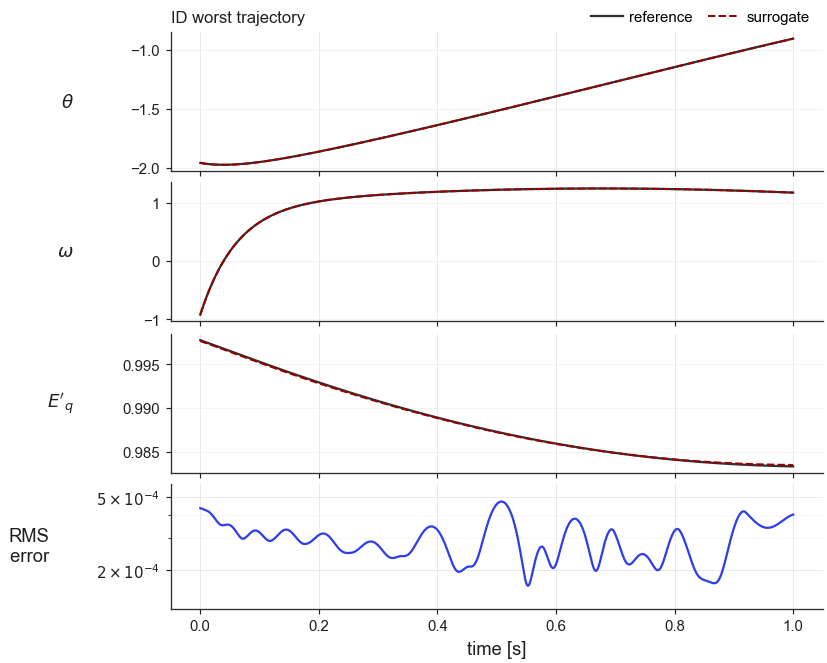

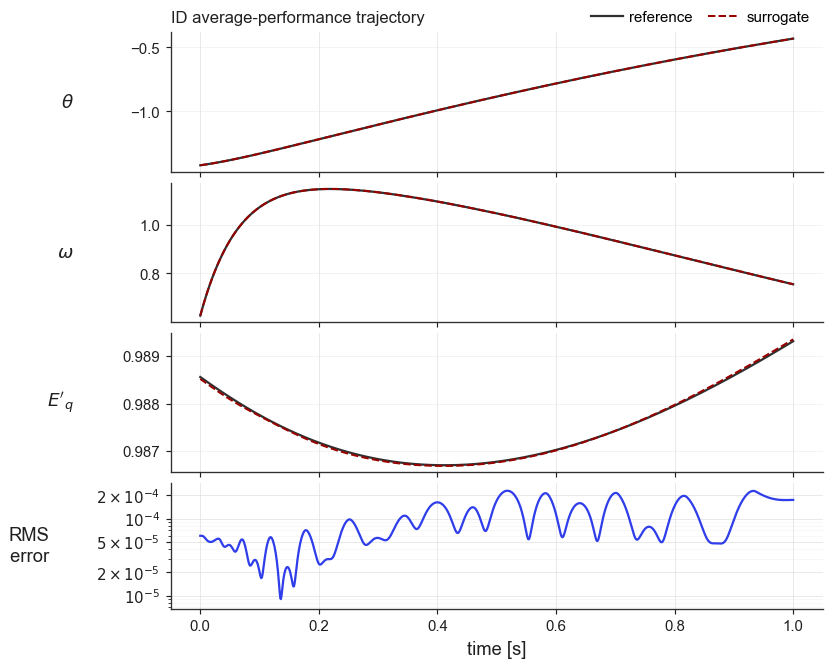

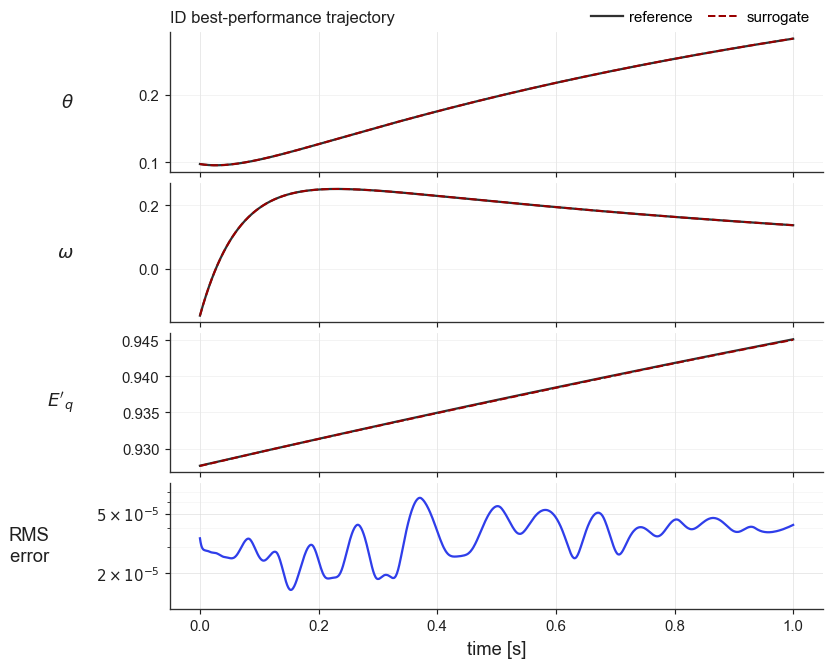

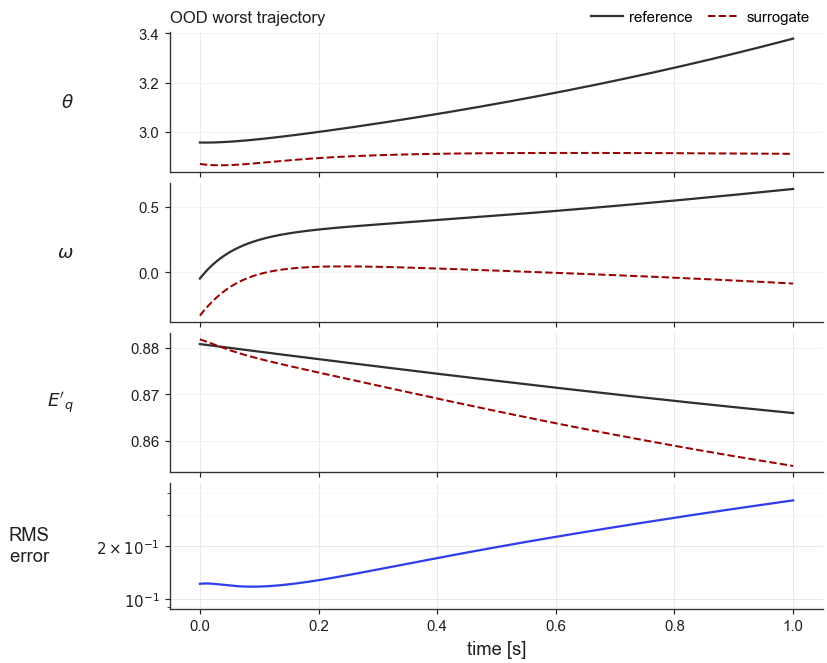

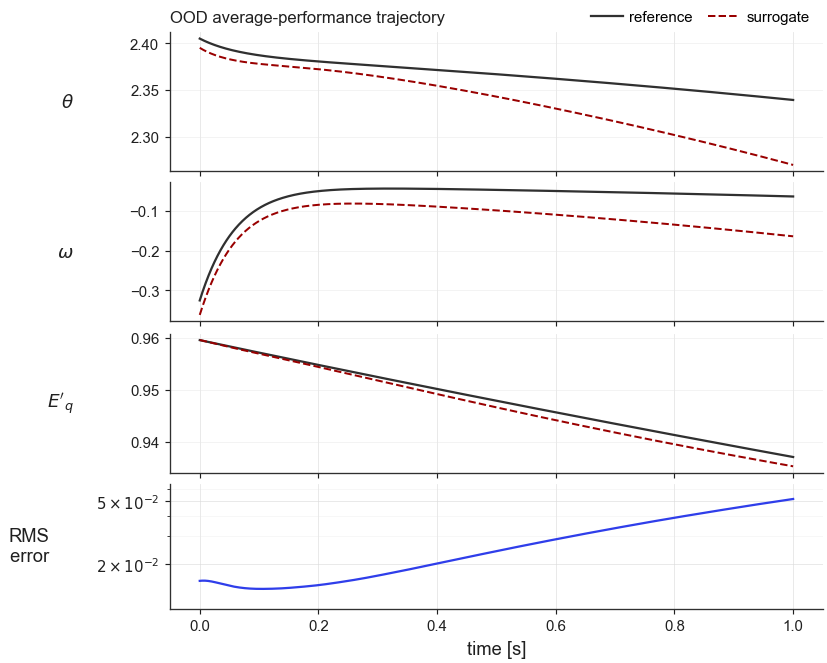

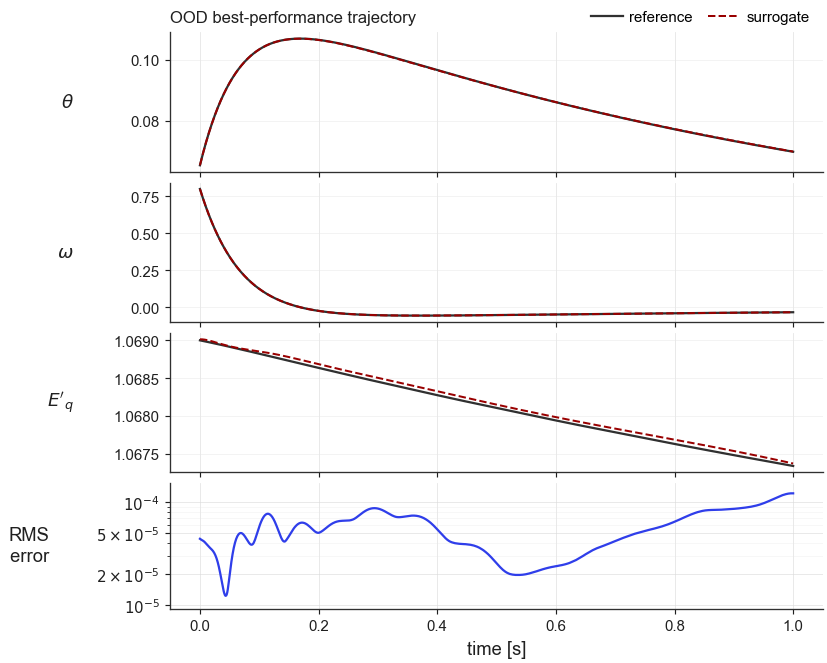

In [6]:
import torch
import matplotlib.pyplot as plt

from src.experiments.pipeline.helpers.posthoc_evaluation import (
    load_ic_bounds_from_config,
    predict_pinn_model_on_evaluation_split,
    row_indices_for_trajectory_mask,
    trajectory_exclusive_ood_mask,
    trajectory_slices_from_rows,
)
from src.training.trainer import PinnModel
from src.visualization.thesis_style import (
    DTU_COLORS,
    NEUTRAL_COLORS,
    apply_thesis_axis_style,
    log_minor_grid,
    save_figure,
)

# Scratch trajectory export directory is intentionally not created for repository submission.

STATE_LABELS = {
    "SM4": [r"$\theta$", r"$\omega$", r"$E'_d$", r"$E'_q$"],
    "SM6": [r"$\theta$", r"$\omega$", r"$E'_d$", r"$E'_q$", r"$E''_d$", r"$E''_q$"],
    "SM_AVR_GOV": [r"$\theta$", r"$\omega$", r"$E'_d$", r"$E'_q$", r"$R_F$", r"$V_r$", r"$E_{fd}$", r"$P_{sv}$", r"$P_m$"],
}
FEATURE_LABELS = {model: labels + [r"$V_s$", r"$\theta_{vs}$"] for model, labels in STATE_LABELS.items()}
REPRESENTATIVE_STATE_INDEX = {
    "SM4": [0, 1, 3],
    "SM6": [0, 1, 3],
    "SM_AVR_GOV": [0, 1, 3],
}
SELECTION_LABEL = {
    "worst": "worst",
    "average": "average-performance",
    "best": "best-performance",
}


def _select_analysis_row(model_flag: str, strategy: str, seed_label: str) -> pd.Series:
    matches = analysis_runs[
        analysis_runs["model_flag"].astype(str).eq(model_flag)
        & analysis_runs["strategy"].astype(str).eq(strategy)
        & analysis_runs["seed_label"].astype(str).eq(seed_label)
    ]
    if matches.empty:
        raise ValueError(f"No posthoc result found for {model_flag}/{strategy}/{seed_label}.")
    return matches.iloc[0]


def _cache_stem(row: pd.Series, *, kind: str, selection: str) -> str:
    return f"{str(row['model_flag']).lower()}_{row['strategy']}_{row['seed_label']}_{kind}_{selection}"


def _load_cached_selected_trajectory(row: pd.Series, *, kind: str, selection: str) -> dict[str, np.ndarray | object] | None:
    """Return no local cache during repository-submission analysis."""

    return None

def _load_filtered_prediction_payload(row: pd.Series, *, kind: str = "ood", batch_size: int = 8192) -> dict[str, object]:
    model_flag = str(row["model_flag"])
    posthoc_payload = load_json(Path(row["posthoc_result_path"]), default={}) or {}
    section = posthoc_payload[kind]
    dataset_root = Path(section["dataset_root"])
    checkpoint_path = Path(section["checkpoint_path"])

    pinn_model = PinnModel.load_checkpoint(str(checkpoint_path), device_preference="cpu")
    prediction = predict_pinn_model_on_evaluation_split(
        pinn_model=pinn_model,
        checkpoint_path=checkpoint_path,
        dataset_root=dataset_root,
        split=str(section["split"]),
        batch_size=batch_size,
    )

    x_eval = prediction.split.x
    y_eval = prediction.split.y
    y_pred = prediction.y_pred
    slices_eval = trajectory_slices_from_rows(x=x_eval, trajectory_ids=prediction.split.trajectory_ids)
    training_bounds = load_ic_bounds_from_config(
        model_flag=model_flag,
        init_condition_bounds=int(posthoc_payload.get("init_condition_bounds", 1)),
        init_conditions_dir=REPO / "src" / "config" / "ic",
    )

    if kind == "ood" and posthoc_payload.get("ood_mode") == "exclusive":
        keep_mask = trajectory_exclusive_ood_mask(
            x=x_eval,
            trajectory_slices=slices_eval,
            training_bounds=training_bounds,
        )
        row_indices = torch.as_tensor(
            row_indices_for_trajectory_mask(trajectory_slices=slices_eval, keep_mask=keep_mask),
            dtype=torch.long,
        )
        x_eval = x_eval.index_select(0, row_indices)
        y_eval = y_eval.index_select(0, row_indices)
        y_pred = y_pred.index_select(0, row_indices)
        slices_eval = trajectory_slices_from_rows(x=x_eval)

    return {
        "posthoc_payload": posthoc_payload,
        "section": section,
        "x_eval": x_eval,
        "y_eval": y_eval,
        "y_pred": y_pred,
        "slices_eval": slices_eval,
        "training_bounds": training_bounds,
        "dataset_root": dataset_root,
        "checkpoint_path": checkpoint_path,
    }


def _extract_selected_trajectory(row: pd.Series, payload: dict[str, object], *, kind: str, selection: str) -> dict[str, np.ndarray | object]:
    if selection not in {"worst", "average", "best"}:
        raise ValueError("selection must be one of: 'worst', 'average', 'best'.")

    x_eval = payload["x_eval"]
    y_eval = payload["y_eval"]
    y_pred = payload["y_pred"]
    slices_eval = payload["slices_eval"]
    training_bounds = payload["training_bounds"]

    diff = (y_pred - y_eval).detach().cpu().numpy()
    trajectory_mse = np.asarray([float(np.mean(diff[item.start:item.stop] ** 2)) for item in slices_eval], dtype=float)
    mean_trajectory_mse = float(np.mean(trajectory_mse))
    if selection == "worst":
        selected_idx = int(np.argmax(trajectory_mse))
    elif selection == "best":
        selected_idx = int(np.argmin(trajectory_mse))
    else:
        selected_idx = int(np.argmin(np.abs(trajectory_mse - mean_trajectory_mse)))

    selected_slice = slices_eval[selected_idx]
    start = int(selected_slice.start)
    stop = int(selected_slice.stop)
    x_seg = x_eval[start:stop].detach().cpu().numpy()
    y_true = y_eval[start:stop].detach().cpu().numpy()
    y_hat = y_pred[start:stop].detach().cpu().numpy()
    abs_error = np.abs(y_hat - y_true)
    rms_error_t = np.sqrt(np.mean((y_hat - y_true) ** 2, axis=1))
    initial_condition = x_seg[0, 1:]
    time = x_seg[:, 0]
    max_abs_error = float(np.max(abs_error))
    trajectory_rmse = float(np.sqrt(trajectory_mse[selected_idx]))

    meta = {
        "model_flag": str(row["model_flag"]),
        "strategy": str(row["strategy"]),
        "seed_label": str(row["seed_label"]),
        "kind": kind,
        "selection": selection,
        "selection_label": SELECTION_LABEL[selection],
        "run_name": str(row["run_name"]),
        "posthoc_result_path": str(row["posthoc_result_path"]),
        "dataset_root": str(payload["dataset_root"]),
        "checkpoint_path": str(payload["checkpoint_path"]),
        "trajectory_index": selected_idx,
        "trajectory_mse": float(trajectory_mse[selected_idx]),
        "trajectory_rmse": trajectory_rmse,
        "trajectory_max_abs_error": max_abs_error,
        "mean_trajectory_mse": mean_trajectory_mse,
        "n_rows": int(stop - start),
    }

    stem = _cache_stem(row, kind=kind, selection=selection)
    # Scratch export disabled for repository submission; keep derived data in memory.
    # np.savez_compressed(
        # time=time,
        # y_true=y_true,
        # y_pred=y_hat,
        # abs_error=abs_error,
        # rms_error_t=rms_error_t,
        # initial_condition=initial_condition,
        # training_bounds=training_bounds,
    # )

    return {
        "time": time,
        "y_true": y_true,
        "y_pred": y_hat,
        "abs_error": abs_error,
        "rms_error_t": rms_error_t,
        "initial_condition": initial_condition,
        "training_bounds": training_bounds,
        "meta": meta,
    }


def _selected_trajectory(row: pd.Series, payload: dict[str, object] | None, *, kind: str, selection: str) -> dict[str, np.ndarray | object]:
    cached = _load_cached_selected_trajectory(row, kind=kind, selection=selection)
    if cached is not None:
        return cached
    if payload is None:
        raise ValueError("A filtered prediction payload is required when the selected trajectory is not cached.")
    return _extract_selected_trajectory(row, payload, kind=kind, selection=selection)


def _trajectory_ic_summary(trajectory: dict[str, np.ndarray | object], model_flag: str, selection: str) -> pd.DataFrame:
    frame = pd.DataFrame({
        "feature": FEATURE_LABELS[model_flag],
        "initial condition": trajectory["initial_condition"],
        "training lower": trajectory["training_bounds"][:, 0],
        "training upper": trajectory["training_bounds"][:, 1],
    })
    frame["outside training range"] = (
        (frame["initial condition"] < frame["training lower"])
        | (frame["initial condition"] > frame["training upper"])
    )
    frame.insert(0, "selection", selection)
    return frame


def _trajectory_summary(trajectory: dict[str, np.ndarray | object]) -> pd.DataFrame:
    meta = trajectory["meta"]
    return pd.DataFrame([{
        "model": MODEL_LABEL[str(meta["model_flag"])],
        "method": STRATEGY_LABEL[str(meta["strategy"])],
        "seed": meta["seed_label"],
        "split": str(meta["kind"]).upper(),
        "selection": meta["selection_label"],
        "trajectory index": meta["trajectory_index"],
        "trajectory MSE": meta["trajectory_mse"],
        "mean trajectory MSE": meta["mean_trajectory_mse"],
        "trajectory RMSE": meta["trajectory_rmse"],
        "trajectory max AE": meta["trajectory_max_abs_error"],
        "rows": meta["n_rows"],
    }])


def _sci_log_tick(value, _position):
    if value <= 0 or not np.isfinite(value):
        return ""
    exponent = int(np.floor(np.log10(value)))
    multiplier = value / (10.0 ** exponent)
    if np.isclose(multiplier, 1.0):
        return rf"$10^{{{exponent}}}$"
    return rf"${multiplier:.0f}\times10^{{{exponent}}}$"


def _set_readable_log_ticks(ax, values: np.ndarray) -> None:
    from matplotlib.ticker import FixedLocator, FuncFormatter, LogLocator, NullFormatter

    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite) & (finite > 0)]
    if finite.size == 0:
        return
    lower = max(float(np.nanmin(finite)) * 0.75, 1e-16)
    upper = float(np.nanmax(finite)) * 1.25
    if not np.isfinite(upper) or upper <= lower:
        upper = lower * 10.0
    if upper / lower < 4.0:
        center = float(np.sqrt(lower * upper))
        lower = max(center / np.sqrt(10.0), 1e-16)
        upper = center * np.sqrt(10.0)
    ax.set_ylim(lower, upper)

    major_ticks = []
    tick_min = int(np.floor(np.log10(lower)))
    tick_max = int(np.ceil(np.log10(upper)))
    for exponent in range(tick_min, tick_max + 1):
        for multiplier in (1, 2, 5):
            tick = multiplier * 10.0 ** exponent
            if lower <= tick <= upper:
                major_ticks.append(tick)
    if len(major_ticks) < 2:
        major_ticks = list(np.geomspace(lower, upper, 3))

    ax.yaxis.set_major_locator(FixedLocator(major_ticks))
    ax.yaxis.set_major_formatter(FuncFormatter(_sci_log_tick))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=80))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(axis="y", which="minor", length=2.0, width=0.5)


def _plot_selected_trajectory(trajectory: dict[str, np.ndarray | object], *, filename: str) -> None:
    meta = trajectory["meta"]
    model_flag = str(meta["model_flag"])
    state_labels = STATE_LABELS[model_flag]
    selected_state_indices = REPRESENTATIVE_STATE_INDEX[model_flag]

    fig, axes = plt.subplots(
        len(selected_state_indices) + 1,
        1,
        figsize=(6.9, 5.45),
        sharex=True,
        constrained_layout=True,
        gridspec_kw={"height_ratios": [1.0] * len(selected_state_indices) + [0.9]},
    )
    fig.set_constrained_layout_pads(h_pad=0.025, hspace=0.035)

    line_handles = []
    line_labels = []
    for ax, state_idx in zip(axes[:-1], selected_state_indices):
        ref_line, = ax.plot(
            trajectory["time"],
            trajectory["y_true"][:, state_idx],
            color=NEUTRAL_COLORS["axis"],
            linewidth=1.35,
            label="reference",
        )
        pred_line, = ax.plot(
            trajectory["time"],
            trajectory["y_pred"][:, state_idx],
            color=DTU_COLORS["corporate_red"],
            linewidth=1.2,
            linestyle="--",
            label="surrogate",
        )
        if not line_handles:
            line_handles = [ref_line, pred_line]
            line_labels = ["reference", "surrogate"]
        ax.set_ylabel(state_labels[state_idx], rotation=0, ha="right", va="center", labelpad=13)
        ax.tick_params(axis="both", which="major", labelsize=9)
        apply_thesis_axis_style(ax)
        ax.grid(True, axis="y", color=NEUTRAL_COLORS["light_grid"], linewidth=0.45, alpha=0.65)

    error_ax = axes[-1]
    positive_error = np.maximum(trajectory["rms_error_t"], 1e-16)
    error_ax.plot(trajectory["time"], positive_error, color=DTU_COLORS["blue"], linewidth=1.35)
    error_ax.set_yscale("log")
    _set_readable_log_ticks(error_ax, positive_error)
    error_ax.set_ylabel("RMS\n error", rotation=0, ha="right", va="center", labelpad=28)
    error_ax.set_xlabel("time [s]")
    error_ax.tick_params(axis="both", which="major", labelsize=9)
    error_ax.grid(True, which="major", axis="y", color=NEUTRAL_COLORS["grid"], linewidth=0.5, alpha=0.7)
    error_ax.grid(True, which="minor", axis="y", color=NEUTRAL_COLORS["light_grid"], linewidth=0.35, alpha=0.55)
    apply_thesis_axis_style(error_ax)

    title = f"{str(meta['kind']).upper()} {meta['selection_label']} trajectory"
    axes[0].set_title(title, loc="left", pad=6, fontsize=10)
    fig.legend(
        line_handles,
        line_labels,
        loc="upper right",
        bbox_to_anchor=(0.985, 1.005),
        ncol=2,
        frameon=False,
        handlelength=2.1,
        columnspacing=1.0,
        borderaxespad=0.0,
    )
    fig.align_ylabels(axes)
    # Figure export disabled for repository submission; keep plot inline.
    plt.show()


representative_row = _select_analysis_row("SM6", "dn_adam3000_ssbroyden2000", "s02")
requested_kinds = ["id", "ood"]
requested_selections = ["worst", "average", "best"]
selected_trajectories = {}

for kind in requested_kinds:
    cached_trajectories = {
        selection: _load_cached_selected_trajectory(representative_row, kind=kind, selection=selection)
        for selection in requested_selections
    }
    filtered_payload = None
    if any(value is None for value in cached_trajectories.values()):
        filtered_payload = _load_filtered_prediction_payload(representative_row, kind=kind, batch_size=8192)
    for selection in requested_selections:
        selected_trajectories[(kind, selection)] = _selected_trajectory(
            representative_row,
            filtered_payload,
            kind=kind,
            selection=selection,
        )

model_flag = str(selected_trajectories[("ood", "worst")]["meta"]["model_flag"])

trajectory_summaries = pd.concat(
    [_trajectory_summary(selected_trajectories[(kind, selection)]) for kind in requested_kinds for selection in requested_selections],
    ignore_index=True,
)
ic_summaries = pd.concat(
    [
        _trajectory_ic_summary(selected_trajectories[(kind, selection)], model_flag, SELECTION_LABEL[selection])
        .assign(split=kind.upper())
        for kind in requested_kinds
        for selection in requested_selections
    ],
    ignore_index=True,
)
# Keep split as the first table column for easier reading.
ic_summaries = ic_summaries[["split", *[col for col in ic_summaries.columns if col != "split"]]]
# Scratch export disabled for repository submission; keep derived data in memory.

for kind in requested_kinds:
    kind_summary = trajectory_summaries[trajectory_summaries["split"].eq(kind.upper())]
    kind_ics = ic_summaries[ic_summaries["split"].eq(kind.upper())]
    # Scratch export disabled for repository submission; keep derived data in memory.
    for selection in requested_selections:
        label = SELECTION_LABEL[selection]
        single_summary = kind_summary[kind_summary["selection"].eq(label)]
        single_ics = kind_ics[kind_ics["selection"].eq(label)]
        # Scratch export disabled for repository submission; keep derived data in memory.

display(trajectory_summaries)
display(ic_summaries)

for kind in requested_kinds:
    for selection in requested_selections:
        _plot_selected_trajectory(
            selected_trajectories[(kind, selection)],
            filename=f"sm6_dn_s02_{selection}_{kind}_trajectory_dynamics",
        )

### Worst ID/OOD Trajectory Comparison

The following side-by-side panel compares the worst selected ID trajectory against the worst selected OOD trajectory for the same SM6 DN+SSBroyden checkpoint. The row labels are shared across both columns so the contrast focuses on how the same observable states and RMS error evolve in-distribution and out-of-distribution.

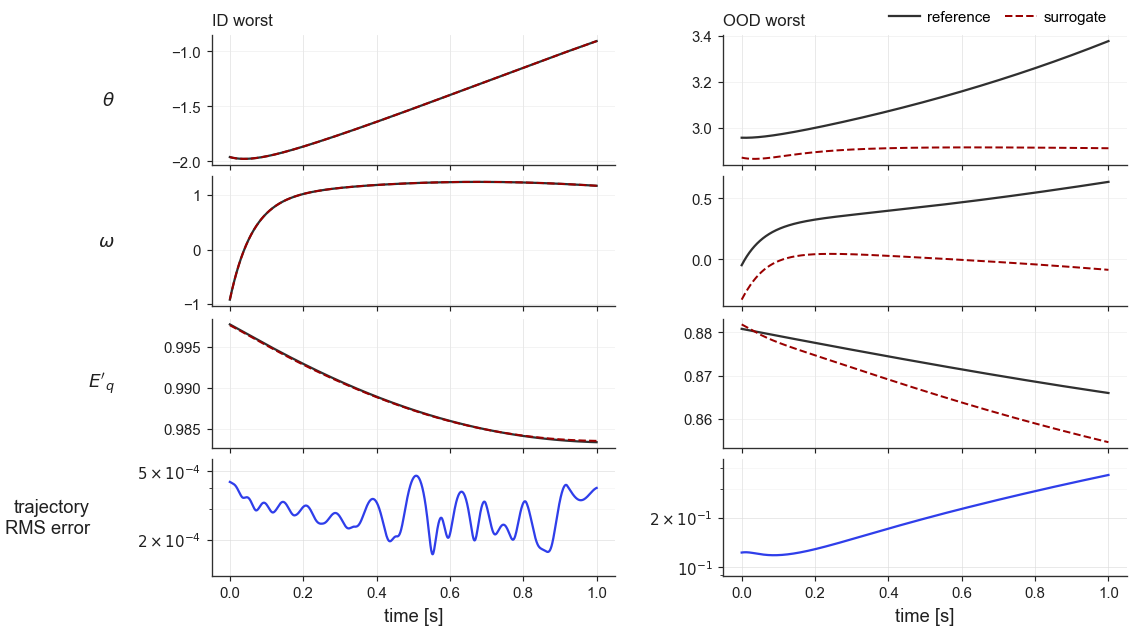

In [7]:
def _plot_worst_id_ood_comparison() -> None:
    comparison = [
        ("ID worst", selected_trajectories[("id", "worst")]),
        ("OOD worst", selected_trajectories[("ood", "worst")]),
    ]
    model_flag = str(comparison[0][1]["meta"]["model_flag"])
    state_labels = STATE_LABELS[model_flag]
    selected_state_indices = REPRESENTATIVE_STATE_INDEX[model_flag]
    n_rows = len(selected_state_indices) + 1

    fig, axes = plt.subplots(
        n_rows,
        2,
        figsize=(9.4, 5.15),
        sharex="col",
        constrained_layout=True,
        gridspec_kw={"height_ratios": [1.0] * len(selected_state_indices) + [0.9], "wspace": 0.06},
    )
    fig.set_constrained_layout_pads(h_pad=0.025, hspace=0.035, w_pad=0.025, wspace=0.035)

    line_handles = []
    line_labels = []
    for col_idx, (title, trajectory) in enumerate(comparison):
        axes[0, col_idx].set_title(title, loc="left", pad=6, fontsize=10)
        for row_idx, state_idx in enumerate(selected_state_indices):
            ax = axes[row_idx, col_idx]
            ref_line, = ax.plot(
                trajectory["time"],
                trajectory["y_true"][:, state_idx],
                color=NEUTRAL_COLORS["axis"],
                linewidth=1.35,
                label="reference",
            )
            pred_line, = ax.plot(
                trajectory["time"],
                trajectory["y_pred"][:, state_idx],
                color=DTU_COLORS["corporate_red"],
                linewidth=1.2,
                linestyle="--",
                label="surrogate",
            )
            if not line_handles:
                line_handles = [ref_line, pred_line]
                line_labels = ["reference", "surrogate"]
            if col_idx == 0:
                ax.set_ylabel(state_labels[state_idx], rotation=0, ha="right", va="center", labelpad=13)
            else:
                ax.set_ylabel("")
            ax.tick_params(axis="both", which="major", labelsize=9)
            apply_thesis_axis_style(ax)
            ax.grid(True, axis="y", color=NEUTRAL_COLORS["light_grid"], linewidth=0.45, alpha=0.65)

        error_ax = axes[-1, col_idx]
        positive_error = np.maximum(trajectory["rms_error_t"], 1e-16)
        error_ax.plot(trajectory["time"], positive_error, color=DTU_COLORS["blue"], linewidth=1.35)
        error_ax.set_yscale("log")
        _set_readable_log_ticks(error_ax, positive_error)
        if col_idx == 0:
            error_ax.set_ylabel("trajectory\nRMS error", rotation=0, ha="right", va="center", labelpad=28)
        else:
            error_ax.set_ylabel("")
        error_ax.set_xlabel("time [s]")
        error_ax.tick_params(axis="both", which="major", labelsize=9)
        error_ax.grid(True, which="major", axis="y", color=NEUTRAL_COLORS["grid"], linewidth=0.5, alpha=0.7)
        error_ax.grid(True, which="minor", axis="y", color=NEUTRAL_COLORS["light_grid"], linewidth=0.35, alpha=0.55)
        apply_thesis_axis_style(error_ax)

    fig.legend(
        line_handles,
        line_labels,
        loc="upper right",
        bbox_to_anchor=(0.985, 1.01),
        ncol=2,
        frameon=False,
        handlelength=2.1,
        columnspacing=1.0,
        borderaxespad=0.0,
    )
    fig.align_ylabels(axes[:, 0])
    # Figure export disabled for repository submission; keep plot inline.
    plt.show()


_plot_worst_id_ood_comparison()

### Trajectory-Level Dynamical Descriptors

The selected trajectories can also be compared through simple dynamical descriptors rather than only pointwise MSE. The descriptors below compare the surrogate against the reference trajectory in terms of integrated error, terminal error, transient peak timing/amplitude, approximate settling behavior, and a visible decay-time estimate for the rotor-angle response. These quantities are intended as interpretable checks against the reference trajectory, complementing the aggregate posthoc metrics.

In [8]:
def _trapz(values: np.ndarray, time: np.ndarray, axis: int = 0) -> np.ndarray:
    if hasattr(np, "trapezoid"):
        return np.trapezoid(values, time, axis=axis)
    return np.trapz(values, time, axis=axis)


def _first_settled_time(signal: np.ndarray, time: np.ndarray, *, final_value: float, tolerance: float) -> float:
    within = np.abs(signal - final_value) <= tolerance
    if not np.any(within):
        return np.nan
    suffix_settled = np.flip(np.cumprod(np.flip(within).astype(int))).astype(bool)
    candidates = np.flatnonzero(suffix_settled)
    return float(time[candidates[0]]) if candidates.size else np.nan


def _visible_decay_tau(signal: np.ndarray, time: np.ndarray, *, final_value: float) -> float:
    deviation = np.abs(signal - final_value)
    scale = float(np.nanmax(deviation)) if deviation.size else np.nan
    if not np.isfinite(scale) or scale <= 0.0:
        return np.nan
    mask = (deviation > max(1e-10, 0.02 * scale)) & (deviation < 0.98 * scale)
    if np.count_nonzero(mask) < 8:
        return np.nan
    slope, _intercept = np.polyfit(time[mask], np.log(deviation[mask]), 1)
    return float(-1.0 / slope) if slope < 0.0 else np.nan


from omegaconf import OmegaConf

from src.pinn.residuals import evaluate_ode_rhs
from src.sim.ode.model_definitions import SynchronousMachineModels


def _run_config_path(row: pd.Series) -> Path:
    if "config_path" in row.index and pd.notna(row["config_path"]):
        candidate = Path(str(row["config_path"]))
        if candidate.exists():
            return candidate
    if "run_dir" in row.index and pd.notna(row["run_dir"]):
        candidate = Path(str(row["run_dir"])) / "config.yaml"
        if candidate.exists():
            return candidate
    payload = load_json(Path(row["posthoc_result_path"]), default={}) or {}
    candidate = Path(str(payload.get("config_path", "")))
    if candidate.exists():
        return candidate
    raise FileNotFoundError(f"Could not resolve config.yaml for run {row.get('run_name', '<unknown>')}")


def _load_local_ode_model(row: pd.Series) -> SynchronousMachineModels:
    config = OmegaConf.load(_run_config_path(row))
    config.dirs.params_dir = str(REPO / "src" / "config" / "params")
    config.PINN_flag = True
    return SynchronousMachineModels(config)


representative_ode_model = _load_local_ode_model(representative_row)


def _finite_difference_derivative(values: np.ndarray, time: np.ndarray) -> np.ndarray:
    if values.shape[0] < 3:
        return np.gradient(values, time, axis=0)
    return np.gradient(values, time, axis=0, edge_order=2)


def _ode_rhs_for_trajectory(
    *,
    trajectory: dict[str, np.ndarray | object],
    states: np.ndarray,
    ode_model: SynchronousMachineModels,
    formulation: str = "odequations",
) -> np.ndarray:
    time = np.asarray(trajectory["time"], dtype=np.float64)
    initial_condition = np.asarray(trajectory["initial_condition"], dtype=np.float64)
    x_context = np.column_stack([time, np.repeat(initial_condition[None, :], len(time), axis=0)])
    state_tensor = torch.as_tensor(states, dtype=torch.float64)
    x_tensor = torch.as_tensor(x_context, dtype=torch.float64)
    with torch.no_grad():
        rhs = evaluate_ode_rhs(
            ode_model=ode_model,
            state_source=state_tensor,
            x=x_tensor,
            formulation=formulation,
        )
    return rhs.detach().cpu().numpy()


def _vector_field_consistency_metrics(
    trajectory: dict[str, np.ndarray | object],
    *,
    ode_model: SynchronousMachineModels,
    formulation: str = "odequations",
) -> dict[str, float]:
    time = np.asarray(trajectory["time"], dtype=np.float64)
    y_true = np.asarray(trajectory["y_true"], dtype=np.float64)
    y_pred = np.asarray(trajectory["y_pred"], dtype=np.float64)

    true_derivative = _finite_difference_derivative(y_true, time)
    pred_derivative = _finite_difference_derivative(y_pred, time)
    true_rhs = _ode_rhs_for_trajectory(trajectory=trajectory, states=y_true, ode_model=ode_model, formulation=formulation)
    pred_rhs = _ode_rhs_for_trajectory(trajectory=trajectory, states=y_pred, ode_model=ode_model, formulation=formulation)

    ref_residual = true_derivative - true_rhs
    pred_residual = pred_derivative - pred_rhs
    rhs_state_error = pred_rhs - true_rhs

    ref_residual_rms_t = np.sqrt(np.mean(ref_residual**2, axis=1))
    pred_residual_rms_t = np.sqrt(np.mean(pred_residual**2, axis=1))
    rhs_state_error_rms_t = np.sqrt(np.mean(rhs_state_error**2, axis=1))
    eps = 1e-16
    return {
        "reference_vector_field_residual_rms_mean": float(np.mean(ref_residual_rms_t)),
        "reference_vector_field_residual_rms_max": float(np.max(ref_residual_rms_t)),
        "surrogate_vector_field_residual_rms_mean": float(np.mean(pred_residual_rms_t)),
        "surrogate_vector_field_residual_rms_max": float(np.max(pred_residual_rms_t)),
        "surrogate_reference_residual_ratio_mean": float(np.mean(pred_residual_rms_t) / max(np.mean(ref_residual_rms_t), eps)),
        "rhs_state_error_rms_mean": float(np.mean(rhs_state_error_rms_t)),
        "rhs_state_error_rms_max": float(np.max(rhs_state_error_rms_t)),
    }


def trajectory_dynamical_descriptors(
    trajectory: dict[str, np.ndarray | object],
    *,
    selected_state_indices: list[int],
    state_labels: list[str],
    ode_model: SynchronousMachineModels,
    formulation: str = "odequations",
) -> dict[str, object]:
    meta = trajectory["meta"]
    time = np.asarray(trajectory["time"], dtype=float)
    y_true = np.asarray(trajectory["y_true"], dtype=float)
    y_pred = np.asarray(trajectory["y_pred"], dtype=float)
    error = y_pred - y_true
    abs_error = np.abs(error)
    squared_error = error**2

    iae_state = _trapz(abs_error, time, axis=0)
    ise_state = _trapz(squared_error, time, axis=0)
    terminal_error = error[-1]
    terminal_rms = float(np.sqrt(np.mean(terminal_error**2)))
    terminal_max_abs = float(np.max(np.abs(terminal_error)))

    peak_time_errors = []
    peak_magnitude_errors = []
    settling_ref = []
    settling_pred = []
    settling_errors = []
    tau_errors = []
    tau_ref_values = []
    tau_pred_values = []

    row: dict[str, object] = {
        "split": str(meta["kind"]).upper(),
        "selection": meta["selection_label"],
        "trajectory_index": meta["trajectory_index"],
        "trajectory_mse": meta["trajectory_mse"],
        "mean_trajectory_mse": meta["mean_trajectory_mse"],
        "iae_state_mean": float(np.mean(iae_state)),
        "iae_state_max": float(np.max(iae_state)),
        "ise_state_mean": float(np.mean(ise_state)),
        "ise_state_max": float(np.max(ise_state)),
        "terminal_rms_error": terminal_rms,
        "terminal_max_abs_error": terminal_max_abs,
    }

    for state_idx in selected_state_indices:
        label = state_labels[state_idx]
        safe_label = label.replace("$", "").replace("\\", "").replace("'", "dash").replace("{", "").replace("}", "").replace("_", "_")
        ref_response = y_true[:, state_idx] - y_true[0, state_idx]
        pred_response = y_pred[:, state_idx] - y_pred[0, state_idx]
        ref_peak_idx = int(np.argmax(np.abs(ref_response)))
        pred_peak_idx = int(np.argmax(np.abs(pred_response)))
        ref_peak_mag = float(np.abs(ref_response[ref_peak_idx]))
        pred_peak_mag = float(np.abs(pred_response[pred_peak_idx]))
        peak_time_error = float(abs(time[pred_peak_idx] - time[ref_peak_idx]))
        peak_mag_error = float(abs(pred_peak_mag - ref_peak_mag))
        peak_time_errors.append(peak_time_error)
        peak_magnitude_errors.append(peak_mag_error)

        ref_range = float(np.nanmax(y_true[:, state_idx]) - np.nanmin(y_true[:, state_idx]))
        tolerance = max(1e-8, 0.02 * ref_range)
        ref_settle = _first_settled_time(
            y_true[:, state_idx],
            time,
            final_value=float(y_true[-1, state_idx]),
            tolerance=tolerance,
        )
        pred_settle = _first_settled_time(
            y_pred[:, state_idx],
            time,
            final_value=float(y_true[-1, state_idx]),
            tolerance=tolerance,
        )
        settle_error = float(abs(pred_settle - ref_settle)) if np.isfinite(ref_settle) and np.isfinite(pred_settle) else np.nan
        settling_ref.append(ref_settle)
        settling_pred.append(pred_settle)
        settling_errors.append(settle_error)

        tau_ref = _visible_decay_tau(y_true[:, state_idx], time, final_value=float(y_true[-1, state_idx]))
        tau_pred = _visible_decay_tau(y_pred[:, state_idx], time, final_value=float(y_true[-1, state_idx]))
        tau_error = float(abs(tau_pred - tau_ref)) if np.isfinite(tau_ref) and np.isfinite(tau_pred) else np.nan
        tau_ref_values.append(tau_ref)
        tau_pred_values.append(tau_pred)
        tau_errors.append(tau_error)

        row[f"{safe_label}_peak_time_error"] = peak_time_error
        row[f"{safe_label}_peak_magnitude_error"] = peak_mag_error
        row[f"{safe_label}_settling_time_ref"] = ref_settle
        row[f"{safe_label}_settling_time_pred"] = pred_settle
        row[f"{safe_label}_settling_time_error"] = settle_error
        row[f"{safe_label}_visible_tau_ref"] = tau_ref
        row[f"{safe_label}_visible_tau_pred"] = tau_pred
        row[f"{safe_label}_visible_tau_error"] = tau_error

    row.update(_vector_field_consistency_metrics(trajectory, ode_model=ode_model, formulation=formulation))
    row.update({
        "peak_time_error_mean": float(np.nanmean(peak_time_errors)),
        "peak_time_error_max": float(np.nanmax(peak_time_errors)),
        "peak_magnitude_error_mean": float(np.nanmean(peak_magnitude_errors)),
        "peak_magnitude_error_max": float(np.nanmax(peak_magnitude_errors)),
        "settling_time_ref_mean": float(np.nanmean(settling_ref)),
        "settling_time_pred_mean": float(np.nanmean(settling_pred)),
        "settling_time_error_mean": float(np.nanmean(settling_errors)) if np.any(np.isfinite(settling_errors)) else np.nan,
        "visible_tau_ref_mean": float(np.nanmean(tau_ref_values)) if np.any(np.isfinite(tau_ref_values)) else np.nan,
        "visible_tau_pred_mean": float(np.nanmean(tau_pred_values)) if np.any(np.isfinite(tau_pred_values)) else np.nan,
        "visible_tau_error_mean": float(np.nanmean(tau_errors)) if np.any(np.isfinite(tau_errors)) else np.nan,
    })
    return row


dynamical_descriptor_rows = []
for kind in requested_kinds:
    for selection in requested_selections:
        trajectory = selected_trajectories[(kind, selection)]
        model_flag = str(trajectory["meta"]["model_flag"])
        dynamical_descriptor_rows.append(
            trajectory_dynamical_descriptors(
                trajectory,
                selected_state_indices=REPRESENTATIVE_STATE_INDEX[model_flag],
                state_labels=STATE_LABELS[model_flag],
                ode_model=representative_ode_model,
                formulation="odequations",
            )
        )

dynamical_descriptors = pd.DataFrame(dynamical_descriptor_rows)
# Scratch export disabled for repository submission; keep derived data in memory.

DYNAMICAL_DESCRIPTOR_DISPLAY = [
    "split",
    "selection",
    "trajectory_mse",
    "iae_state_mean",
    "ise_state_mean",
    "terminal_rms_error",
    "peak_time_error_mean",
    "peak_magnitude_error_mean",
    "settling_time_error_mean",
    "visible_tau_error_mean",
    "reference_vector_field_residual_rms_mean",
    "surrogate_vector_field_residual_rms_mean",
    "surrogate_reference_residual_ratio_mean",
    "rhs_state_error_rms_mean",
]
display(dynamical_descriptors[DYNAMICAL_DESCRIPTOR_DISPLAY])

/var/folders/v4/lzkm2zzd3gb0q8rqggx5drch0000gn/T/ipykernel_19745/1847409469.py:223: RuntimeWarning: Mean of empty slice
  "settling_time_pred_mean": float(np.nanmean(settling_pred)),


,split,selection,trajectory_mse,iae_state_mean,ise_state_mean,terminal_rms_error,peak_time_error_mean,peak_magnitude_error_mean,settling_time_error_mean,visible_tau_error_mean,reference_vector_field_residual_rms_mean,surrogate_vector_field_residual_rms_mean,surrogate_reference_residual_ratio_mean,rhs_state_error_rms_mean
0,ID,worst,8.898063e-08,0.000221,8.889567e-08,0.000400,0.001667,0.000120,0.011333,0.001658,0.005838,0.005309,0.909341,0.006164
1,ID,average-performance,1.367997e-08,0.000073,1.367655e-08,0.000175,0.000000,0.000060,0.002000,0.005844,0.004127,0.001107,0.268277,0.002038
2,ID,best-performance,1.365432e-09,0.000028,1.365328e-09,0.000042,0.000333,0.000062,0.001667,0.000840,0.000810,0.000558,0.688963,0.000575
3,OOD,worst,5.012969e-02,0.138198,5.010582e-02,0.364631,0.376333,0.232172,NaN,10.185892,0.001894,1.984801,1047.713591,1.800508
4,OOD,average-performance,8.641133e-04,0.018102,8.635248e-04,0.051564,0.020333,0.020925,NaN,0.057440,0.001247,0.269097,215.803811,0.241902
5,OOD,best-performance,3.755819e-09,0.000045,3.751254e-09,0.000121,0.000000,0.000035,0.008333,0.007818,0.000498,0.000983,1.975113,0.000872


## Loss Landscape Visualizations

The loss-landscape artifacts are loaded from the final thesis landscape runs. Figures use log-scaled loss values, mark the base checkpoint at `(0, 0)`, and use shared color normalization inside each comparison so visual differences are meaningful within the panel.

In [9]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

from src.visualization.thesis_style import (
    DTU_COLORS,
    NEUTRAL_COLORS,
    apply_thesis_axis_style,
    save_figure,
)

LANDSCAPE_ROOT = ROOT / "loss_landscapes_thesis"
# Scratch landscape export directory is intentionally not created for repository submission.

LOSS_LABEL = {
    "total": "total",
    "data": "data",
    "dt": "dt",
    "physics": "physics",
    "ic": "IC",
}
CHECKPOINT_LABEL = {
    "init": "init",
    "epoch_060pct": "60%",
    "epoch_100pct": "100%",
    "best": "best",
}
SHORT_METHOD_LABEL = {
    "data_only_adam_5000": "Data-only Adam",
    "dn_adam3000_ssbroyden2000": "DN + SSBroyden",
    "ssbroyden_5000": "SSBroyden",
}
SHORT_MODEL_LABEL = {
    "SM4": "SM4",
    "SM6": "SM6",
    "SM_AVR_GOV": "SM9",
}


def safe_log10(values: np.ndarray, eps: float = 1e-16) -> np.ndarray:
    return np.log10(np.maximum(np.asarray(values, dtype=float), eps))


def load_landscape_dir(path: Path) -> dict:
    manifest = load_json(path / "manifest.json", default={}) or {}
    coords = np.load(path / "coordinates.npz")
    losses = {loss_path.stem.replace("loss_", ""): np.load(loss_path) for loss_path in sorted(path.glob("loss_*.npy"))}
    return {
        "path": path,
        "manifest": manifest,
        "alpha": coords["alpha"],
        "beta": coords["beta"],
        "losses": losses,
    }


def landscape_path(group: str, model: str, strategy: str, checkpoint: str, seed: str = "s02") -> Path:
    return LANDSCAPE_ROOT / group / model / strategy / seed / checkpoint


def summarize_landscape(path: Path) -> list[dict[str, object]]:
    landscape = load_landscape_dir(path)
    alpha = landscape["alpha"]
    beta = landscape["beta"]
    center = (int(np.argmin(np.abs(alpha))), int(np.argmin(np.abs(beta))))
    parts = path.relative_to(LANDSCAPE_ROOT).parts
    group = parts[0]
    model, strategy, seed, checkpoint = parts[-4], parts[-3], parts[-2], parts[-1]
    rows = []
    for loss_name, values in landscape["losses"].items():
        min_idx = np.unravel_index(int(np.nanargmin(values)), values.shape)
        rows.append({
            "group": group,
            "model_flag": model,
            "strategy": strategy,
            "seed_label": seed,
            "checkpoint": checkpoint,
            "loss": loss_name,
            "weight_source": landscape["manifest"].get("weight_source"),
            "center_value": float(values[center]),
            "min_value": float(values[min_idx]),
            "max_value": float(np.nanmax(values)),
            "dynamic_range": float(np.nanmax(values) - np.nanmin(values)),
            "min_alpha": float(alpha[min_idx[0]]),
            "min_beta": float(beta[min_idx[1]]),
            "center_is_grid_min": bool(np.isclose(values[center], values[min_idx])),
        })
    return rows


landscape_dirs = sorted(path.parent for path in LANDSCAPE_ROOT.glob("**/coordinates.npz"))
landscape_summary = pd.DataFrame([row for path in landscape_dirs for row in summarize_landscape(path)])
# Scratch export disabled for repository submission; keep derived data in memory.
print(f"loaded landscape directories: {len(landscape_dirs)}")
display(landscape_summary[landscape_summary["loss"].eq("total")][[
    "group", "model_flag", "strategy", "checkpoint", "weight_source", "center_value", "min_value", "max_value", "center_is_grid_min"
]])

loaded landscape directories: 14


,group,model_flag,strategy,checkpoint,weight_source,center_value,min_value,max_value,center_is_grid_min
4,sm6_evolution_existing_s02,SM6,data_only_adam_5000,best,config,7.438725e-07,7.438725e-07,0.643392,True
9,sm6_evolution_existing_s02,SM6,data_only_adam_5000,epoch_060pct,config,1.764835e-06,1.764835e-06,0.899396,True
14,sm6_evolution_existing_s02,SM6,data_only_adam_5000,epoch_100pct,config,1.327296e-05,1.327296e-05,0.701841,True
19,sm6_evolution_existing_s02,SM6,dn_adam3000_ssbroyden2000,best,checkpoint,1.394955e-04,1.394955e-04,21266.496886,True
24,sm6_evolution_existing_s02,SM6,dn_adam3000_ssbroyden2000,epoch_060pct,checkpoint,9.416199e-03,9.416199e-03,841.284680,True
29,sm6_evolution_existing_s02,SM6,dn_adam3000_ssbroyden2000,epoch_100pct,checkpoint,1.394955e-04,1.394955e-04,21266.496886,True
34,sm6_evolution_init_s02,SM6,data_only_adam_5000,init,config,5.835850e-01,5.376647e-01,0.902889,False
39,sm6_evolution_init_s02,SM6,dn_adam3000_ssbroyden2000,init,config,5.851242e-01,5.410634e-01,0.905314,False
44,ssb_model_order_best_s02,SM4,ssbroyden_5000,best,config,4.001202e-08,4.001202e-08,77.095450,True
49,ssb_model_order_best_s02,SM6,ssbroyden_5000,best,config,8.750227e-09,8.750227e-09,43.103000,True


In [10]:
def _plot_heatmap_panel(
    ax,
    landscape: dict,
    loss_name: str,
    *,
    norm: Normalize,
    cmap: str = "viridis",
    title: str = "",
    show_ylabel: bool = False,
    show_xlabel: bool = True,
):
    alpha = landscape["alpha"]
    beta = landscape["beta"]
    display = safe_log10(landscape["losses"][loss_name])
    B, A = np.meshgrid(beta, alpha)
    mesh = ax.contourf(B, A, display, levels=np.linspace(norm.vmin, norm.vmax, 18), cmap=cmap, norm=norm, extend="both")
    ax.contour(B, A, display, levels=np.linspace(norm.vmin, norm.vmax, 9), colors="white", linewidths=0.25, alpha=0.45)
    ax.scatter([0.0], [0.0], s=15, marker="+", c=NEUTRAL_COLORS["text"], linewidths=0.9, zorder=5)
    ax.set_title(title, pad=4)
    ax.set_xlabel(r"$\beta$" if show_xlabel else "")
    ax.set_ylabel(r"$\alpha$" if show_ylabel else "")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(False)
    apply_thesis_axis_style(ax)
    return mesh


def _shared_norm(landscapes: list[dict], loss_name: str, q_low: float = 0.0, q_high: float = 1.0) -> Normalize:
    values = np.concatenate([safe_log10(item["losses"][loss_name]).ravel() for item in landscapes])
    values = values[np.isfinite(values)]
    vmin = float(np.quantile(values, q_low))
    vmax = float(np.quantile(values, q_high))
    if np.isclose(vmin, vmax):
        vmax = vmin + 1.0
    return Normalize(vmin=vmin, vmax=vmax)


def save_landscape_figure(fig, name: str):
    # Figure export disabled for repository submission; keep plot inline.
    paths = []
    plt.show()
    return paths

### Model-Order Landscapes

The following panels compare SSBroyden landscapes across increasing synchronous-machine model order. The initialization panels show the much larger raw physics residual scale for the AVR/GOV model, while the best-checkpoint panels show the optimized basins.

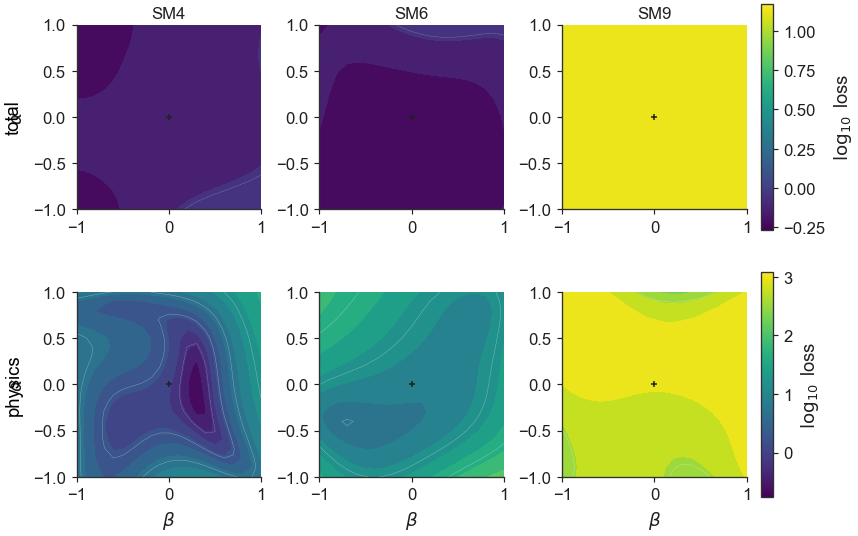

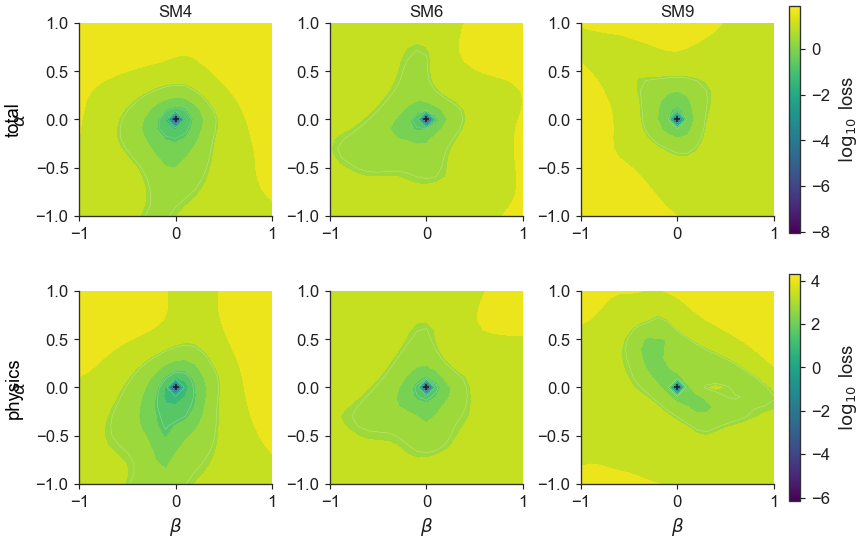

In [11]:
def plot_model_order_landscapes(checkpoint: str, filename: str) -> None:
    models = ["SM4", "SM6", "SM_AVR_GOV"]
    losses = ["total", "physics"]
    landscapes = {
        (model, loss): load_landscape_dir(landscape_path(
            "ssb_model_order_init_s02" if checkpoint == "init" else "ssb_model_order_best_s02",
            model,
            "ssbroyden_5000",
            checkpoint,
        ))
        for model in models
        for loss in losses
    }
    norms = {loss: _shared_norm([landscapes[(model, loss)] for model in models], loss) for loss in losses}

    fig, axes = plt.subplots(2, 3, figsize=(7.2, 4.7), constrained_layout=True)
    for row_idx, loss in enumerate(losses):
        for col_idx, model in enumerate(models):
            _plot_heatmap_panel(
                axes[row_idx, col_idx],
                landscapes[(model, loss)],
                loss,
                norm=norms[loss],
                title=SHORT_MODEL_LABEL[model] if row_idx == 0 else "",
                show_ylabel=col_idx == 0,
                show_xlabel=row_idx == len(losses) - 1,
            )
            if col_idx == 0:
                axes[row_idx, col_idx].text(
                    -0.34, 0.5, LOSS_LABEL[loss], transform=axes[row_idx, col_idx].transAxes,
                    rotation=90, ha="center", va="center", fontsize=11,
                )
        sm = ScalarMappable(norm=norms[loss], cmap="viridis")
        cbar = fig.colorbar(sm, ax=axes[row_idx, :], shrink=0.88, pad=0.015)
        cbar.set_label(r"$\log_{10}$ loss")
    save_landscape_figure(fig, filename)

plot_model_order_landscapes("init", "landscape_ssb_model_order_init_total_physics")
plot_model_order_landscapes("best", "landscape_ssb_model_order_best_total_physics")

### SM6 Optimization Evolution

The SM6 panels compare how the sampled loss basin evolves for data-only Adam and DN+SSBroyden. The DN trained checkpoints use checkpoint-stored adaptive weights for the total objective; the initialization uses config weights because no adaptive checkpoint weights exist before training.

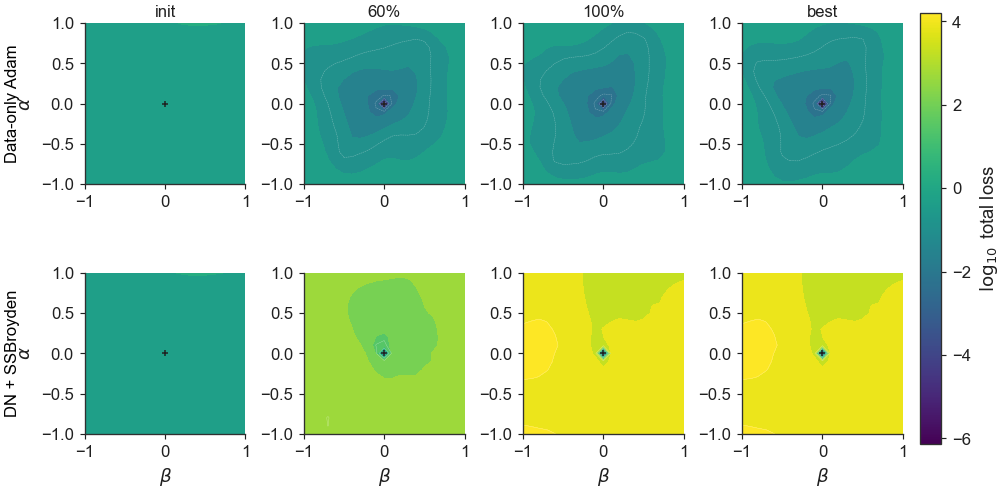

[]

In [12]:
checkpoints = ["init", "epoch_060pct", "epoch_100pct", "best"]
strategies = ["data_only_adam_5000", "dn_adam3000_ssbroyden2000"]
landscapes = {}
for strategy in strategies:
    for checkpoint in checkpoints:
        group = "sm6_evolution_init_s02" if checkpoint == "init" else "sm6_evolution_existing_s02"
        landscapes[(strategy, checkpoint)] = load_landscape_dir(landscape_path(group, "SM6", strategy, checkpoint))

norm = _shared_norm(list(landscapes.values()), "total", q_low=0.0, q_high=0.98)
fig, axes = plt.subplots(2, 4, figsize=(8.4, 4.35), constrained_layout=True)
for row_idx, strategy in enumerate(strategies):
    for col_idx, checkpoint in enumerate(checkpoints):
        _plot_heatmap_panel(
            axes[row_idx, col_idx],
            landscapes[(strategy, checkpoint)],
            "total",
            norm=norm,
            title=CHECKPOINT_LABEL[checkpoint] if row_idx == 0 else "",
            show_ylabel=col_idx == 0,
            show_xlabel=row_idx == len(strategies) - 1,
        )
        if col_idx == 0:
            axes[row_idx, col_idx].text(
                -0.45, 0.5, SHORT_METHOD_LABEL[strategy], transform=axes[row_idx, col_idx].transAxes,
                rotation=90, ha="center", va="center", fontsize=10,
            )
sm = ScalarMappable(norm=norm, cmap="viridis")
cbar = fig.colorbar(sm, ax=axes, shrink=0.88, pad=0.015)
cbar.set_label(r"$\log_{10}$ total loss")
save_landscape_figure(fig, "landscape_sm6_optimization_evolution_total")

### Component Landscapes

The component panel shows how the same checkpoint can be smooth or sharp depending on the objective term. This is useful for explaining why a single total-loss landscape can hide competing geometries in the PINN objective.

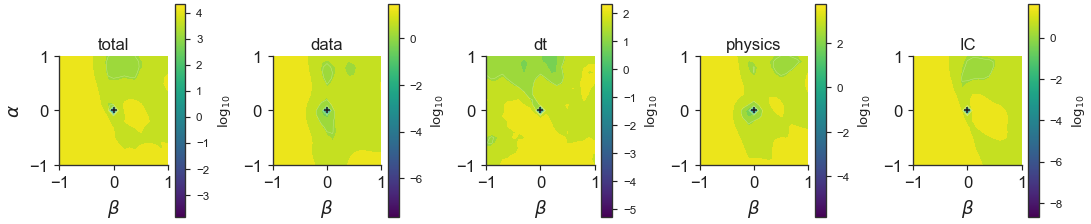

[]

In [13]:
component_landscape = load_landscape_dir(landscape_path(
    "sm6_evolution_existing_s02",
    "SM6",
    "dn_adam3000_ssbroyden2000",
    "best",
))
component_losses = ["total", "data", "dt", "physics", "ic"]
fig, axes = plt.subplots(1, len(component_losses), figsize=(9.1, 2.45), constrained_layout=True)
for ax, loss in zip(axes, component_losses):
    norm = _shared_norm([component_landscape], loss)
    _plot_heatmap_panel(
        ax,
        component_landscape,
        loss,
        norm=norm,
        title=LOSS_LABEL[loss],
        show_ylabel=ax is axes[0],
        show_xlabel=True,
    )
    sm = ScalarMappable(norm=norm, cmap="viridis")
    cbar = fig.colorbar(sm, ax=ax, shrink=0.75, pad=0.02)
    cbar.ax.tick_params(labelsize=7)
    cbar.set_label(r"$\log_{10}$", fontsize=8)
save_landscape_figure(fig, "landscape_sm6_dn_best_components")

### Component Evolution: Data And Physics

For the optimization story, the data and physics components are the most interpretable pair: the supervised fit decreases smoothly, while physics residual geometry can dominate the PINN objective away from the trained basin.

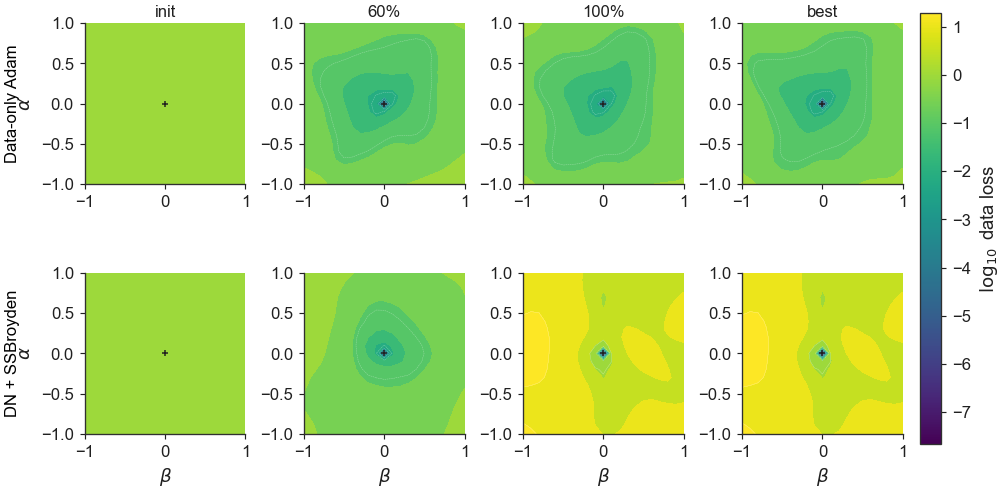

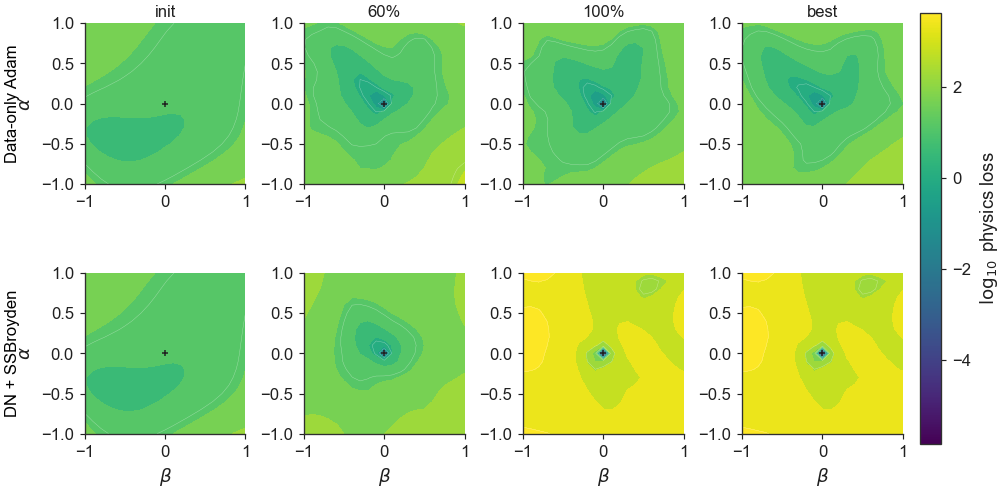

In [14]:
for loss in ["data", "physics"]:
    component_landscapes = {}
    for strategy in strategies:
        for checkpoint in checkpoints:
            group = "sm6_evolution_init_s02" if checkpoint == "init" else "sm6_evolution_existing_s02"
            component_landscapes[(strategy, checkpoint)] = load_landscape_dir(landscape_path(group, "SM6", strategy, checkpoint))
    norm = _shared_norm(list(component_landscapes.values()), loss, q_low=0.0, q_high=0.98)
    fig, axes = plt.subplots(2, 4, figsize=(8.4, 4.35), constrained_layout=True)
    for row_idx, strategy in enumerate(strategies):
        for col_idx, checkpoint in enumerate(checkpoints):
            _plot_heatmap_panel(
                axes[row_idx, col_idx],
                component_landscapes[(strategy, checkpoint)],
                loss,
                norm=norm,
                title=CHECKPOINT_LABEL[checkpoint] if row_idx == 0 else "",
                show_ylabel=col_idx == 0,
                show_xlabel=row_idx == len(strategies) - 1,
            )
            if col_idx == 0:
                axes[row_idx, col_idx].text(
                    -0.45, 0.5, SHORT_METHOD_LABEL[strategy], transform=axes[row_idx, col_idx].transAxes,
                    rotation=90, ha="center", va="center", fontsize=10,
                )
    sm = ScalarMappable(norm=norm, cmap="viridis")
    cbar = fig.colorbar(sm, ax=axes, shrink=0.88, pad=0.015)
    cbar.set_label(rf"$\log_{{10}}$ {LOSS_LABEL[loss]} loss")
    save_landscape_figure(fig, f"landscape_sm6_optimization_evolution_{loss}")

### 3D Landscape Surfaces

The 3D views are exported as supplementary thesis assets. They use the same log-scaled loss values as the heatmaps, but are intended for qualitative intuition rather than precise comparison.

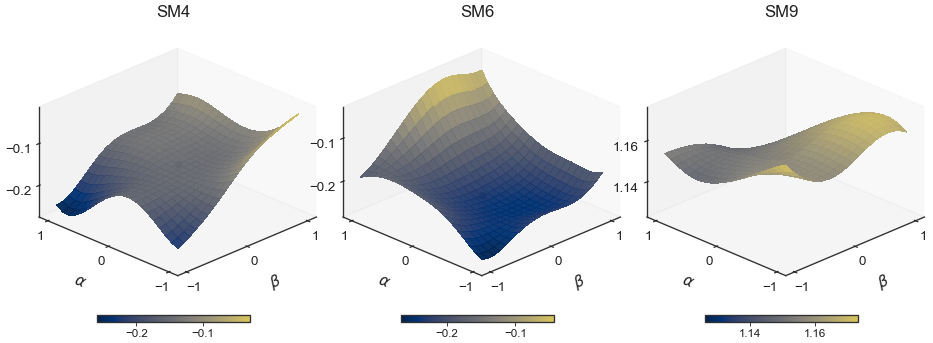

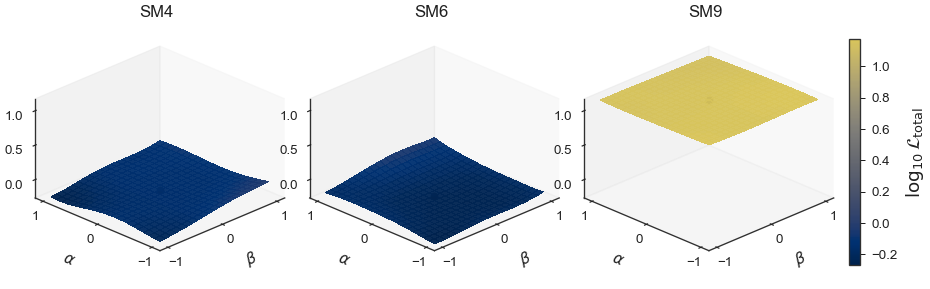

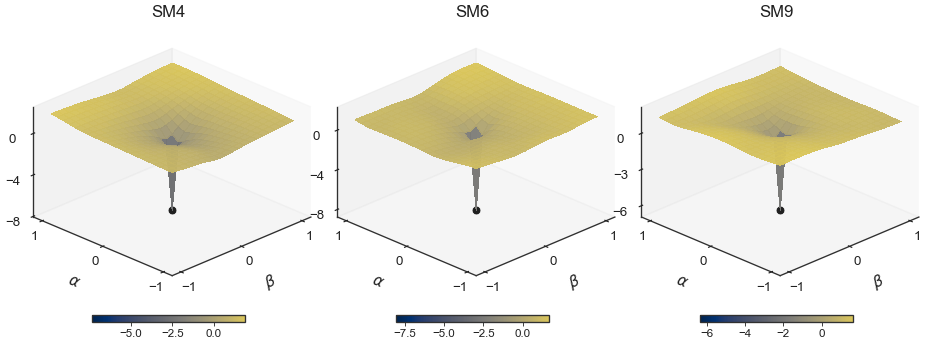

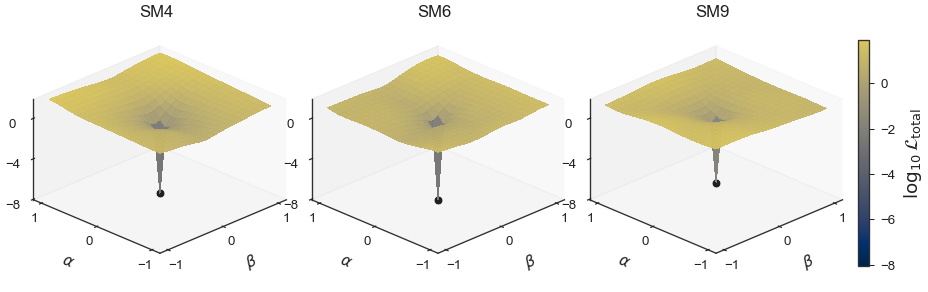

In [15]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import LinearSegmentedColormap


def _truncated_cmap(name: str, *, min_value: float = 0.0, max_value: float = 0.88, n: int = 256):
    base = plt.get_cmap(name)
    return LinearSegmentedColormap.from_list(
        f"{name}_truncated_{min_value:.2f}_{max_value:.2f}",
        base(np.linspace(min_value, max_value, n)),
    )


MODEL_ORDER_3D_CMAP = _truncated_cmap("cividis", max_value=0.86)


def _landscape_log_values(landscape: dict, loss_name: str) -> np.ndarray:
    values = safe_log10(landscape["losses"][loss_name])
    return values[np.isfinite(values)]


def _panel_norm(landscape: dict, loss_name: str, *, q_low: float = 0.0, q_high: float = 1.0) -> Normalize:
    values = _landscape_log_values(landscape, loss_name)
    return Normalize(
        vmin=float(np.nanquantile(values, q_low)),
        vmax=float(np.nanquantile(values, q_high)),
    )


def _plot_surface_panel(
    ax,
    landscape: dict,
    loss_name: str,
    *,
    norm: Normalize,
    title: str = "",
    cmap: str = MODEL_ORDER_3D_CMAP,
    zlim: tuple[float, float] | None = None,
    show_axis_labels: bool = True,
):
    alpha = landscape["alpha"]
    beta = landscape["beta"]
    B, A = np.meshgrid(beta, alpha)
    Z = safe_log10(landscape["losses"][loss_name])
    surf = ax.plot_surface(
        B,
        A,
        Z,
        cmap=cmap,
        norm=norm,
        linewidth=0,
        antialiased=False,
        edgecolor="none",
        rcount=Z.shape[0],
        ccount=Z.shape[1],
        alpha=0.96,
        shade=False,
    )
    center_z = Z[Z.shape[0] // 2, Z.shape[1] // 2]
    ax.scatter(
        [0.0],
        [0.0],
        [center_z],
        c=NEUTRAL_COLORS["text"],
        edgecolor="white",
        linewidth=0.45,
        s=28,
        depthshade=False,
        zorder=10,
    )
    ax.set_title(title, pad=1.5)
    if show_axis_labels:
        ax.set_xlabel(r"$\beta$", labelpad=-2)
        ax.set_ylabel(r"$\alpha$", labelpad=-2)
    else:
        ax.set_xlabel("")
        ax.set_ylabel("")
    ax.set_zlabel("")
    ax.set_xticks([-1.0, 0.0, 1.0])
    ax.set_yticks([-1.0, 0.0, 1.0])
    ax.zaxis.set_major_locator(MaxNLocator(3))
    if zlim is not None:
        ax.set_zlim(*zlim)
    ax.view_init(elev=25, azim=-135)
    ax.set_proj_type("ortho")
    ax.set_box_aspect((1.0, 1.0, 0.62))
    ax.grid(False)
    ax.tick_params(axis="both", which="major", pad=-3, labelsize=8)
    ax.zaxis.set_tick_params(pad=-1, labelsize=8)
    ax.xaxis.label.set_size(9)
    ax.yaxis.label.set_size(9)
    ax.title.set_size(10)
    return surf


def plot_3d_surface_row(
    items: list[tuple[str, dict]],
    loss_name: str,
    filename: str,
    *,
    figsize=(8.0, 2.8),
    cmap: str = MODEL_ORDER_3D_CMAP,
    shared_color: bool = True,
    shared_zlim: bool = True,
    colorbar_label: str | None = None,
) -> None:
    landscapes = [landscape for _, landscape in items]
    if shared_color:
        norms = [_shared_norm(landscapes, loss_name)] * len(items)
    else:
        norms = [_panel_norm(landscape, loss_name) for landscape in landscapes]

    all_values = np.concatenate([_landscape_log_values(landscape, loss_name) for landscape in landscapes])
    zlim = (float(np.nanmin(all_values)), float(np.nanmax(all_values))) if shared_zlim else None

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    axes = []
    for idx, ((title, landscape), norm) in enumerate(zip(items, norms), start=1):
        ax = fig.add_subplot(1, len(items), idx, projection="3d")
        _plot_surface_panel(
            ax,
            landscape,
            loss_name,
            norm=norm,
            title=title,
            cmap=cmap,
            zlim=zlim,
            show_axis_labels=True,
        )
        axes.append(ax)

    if shared_color:
        sm = ScalarMappable(norm=norms[0], cmap=cmap)
        cbar = fig.colorbar(sm, ax=axes, shrink=0.68, pad=0.014, location="right")
        cbar.set_label(colorbar_label or rf"$\log_{{10}}\mathcal{{L}}_{{\mathrm{{{loss_name}}}}}$")
        cbar.ax.tick_params(labelsize=8, length=3, width=0.6)
    else:
        # Relative colour variant: z-axis values remain absolute, while colours
        # reveal local shape inside each panel. The caption should state this.
        for ax, norm in zip(axes, norms):
            sm = ScalarMappable(norm=norm, cmap=cmap)
            cbar = fig.colorbar(sm, ax=ax, shrink=0.52, pad=0.004, location="bottom")
            cbar.ax.tick_params(labelsize=7, length=2.5, width=0.5, pad=1)

    save_landscape_figure(fig, filename)


def plot_model_order_3d_landscapes(checkpoint: str, group: str, suffix: str) -> None:
    items = [
        (SHORT_MODEL_LABEL[model], load_landscape_dir(landscape_path(group, model, "ssbroyden_5000", checkpoint)))
        for model in ["SM4", "SM6", "SM_AVR_GOV"]
    ]
    # Main thesis figure: local colour and z-axis scaling preserve the landscape
    # geometry in each model order. Absolute loss scales are still readable from
    # the z ticks / per-panel colourbars and should be discussed in the caption.
    plot_3d_surface_row(
        items,
        "total",
        f"landscape_3d_ssb_model_order_{suffix}_total",
        figsize=(7.6, 2.95),
        shared_color=False,
        shared_zlim=False,
        colorbar_label=r"$\log_{10}\mathcal{L}_{\mathrm{total}}$",
    )
    # Diagnostic absolute-scale export: useful to show the loss-scale separation,
    # but not ideal as the main thesis visual because local shape is compressed.
    plot_3d_surface_row(
        items,
        "total",
        f"landscape_3d_ssb_model_order_{suffix}_total_absolute_scale",
        figsize=(7.6, 2.85),
        shared_color=True,
        shared_zlim=True,
        colorbar_label=r"$\log_{10}\mathcal{L}_{\mathrm{total}}$",
    )


# Model-order intuition: SSBroyden at initialization and after optimization.
for checkpoint, group, suffix in [
    ("init", "ssb_model_order_init_s02", "init"),
    ("best", "ssb_model_order_best_s02", "best"),
]:
    plot_model_order_3d_landscapes(checkpoint, group, suffix)

# SM6 optimization evolution: compact surfaces for the total objective.
# for strategy in ["data_only_adam_5000", "dn_adam3000_ssbroyden2000"]:
#     items = []
#     for checkpoint in ["init", "epoch_060pct", "epoch_100pct", "best"]:
#         group = "sm6_evolution_init_s02" if checkpoint == "init" else "sm6_evolution_existing_s02"
#         items.append((CHECKPOINT_LABEL[checkpoint], load_landscape_dir(landscape_path(group, "SM6", strategy, checkpoint))))
#     plot_3d_surface_row(
#         items,
#         "total",
#         f"landscape_3d_sm6_{strategy}_evolution_total",
#         figsize=(10.2, 3.0),
#     )

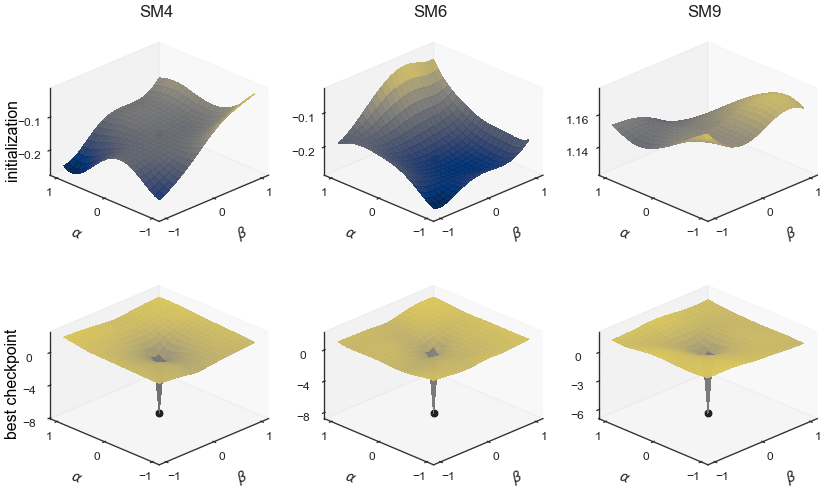

[]

In [16]:
# Combined model-order landscape figure for thesis use.
# Rows correspond to optimization state and columns to model order. Each panel
# uses its own colour normalization so the local landscape geometry remains
# visible. Absolute loss levels are read from the z-axis ticks.
model_order_states = [
    ("init", "ssb_model_order_init_s02", "initialization"),
    ("best", "ssb_model_order_best_s02", "best checkpoint"),
]
model_order_models = ["SM4", "SM6", "SM_AVR_GOV"]
model_order_landscapes = {
    (checkpoint, model): load_landscape_dir(landscape_path(group, model, "ssbroyden_5000", checkpoint))
    for checkpoint, group, _label in model_order_states
    for model in model_order_models
}

panel_norms = {
    (checkpoint, model): _panel_norm(model_order_landscapes[(checkpoint, model)], "total")
    for checkpoint, _group, _label in model_order_states
    for model in model_order_models
}

fig = plt.figure(figsize=(7.25, 4.45), constrained_layout=False)
grid = fig.add_gridspec(
    2,
    3,
    wspace=0.02,
    hspace=0.05,
)
for row_idx, (checkpoint, _group, row_label) in enumerate(model_order_states):
    for col_idx, model in enumerate(model_order_models):
        ax = fig.add_subplot(grid[row_idx, col_idx], projection="3d")
        _plot_surface_panel(
            ax,
            model_order_landscapes[(checkpoint, model)],
            "total",
            norm=panel_norms[(checkpoint, model)],
            title=SHORT_MODEL_LABEL[model] if row_idx == 0 else "",
            cmap=MODEL_ORDER_3D_CMAP,
            zlim=None,
            show_axis_labels=True,
        )
        ax.tick_params(axis="both", which="major", labelsize=7.2, pad=-3)
        ax.zaxis.set_tick_params(labelsize=7.2, pad=-1)
        ax.xaxis.label.set_size(8.2)
        ax.yaxis.label.set_size(8.2)
        ax.title.set_size(10)
        if col_idx == 0:
            ax.text2D(
                -0.12,
                0.48,
                row_label,
                transform=ax.transAxes,
                rotation=90,
                ha="center",
                va="center",
                fontsize=9.5,
            )

fig.subplots_adjust(left=0.045, right=0.985, top=0.94, bottom=0.05)
save_landscape_figure(fig, "landscape_3d_ssb_model_order_init_best_total")

### 3D DN Component Evolution

This panel shows the SM6 DN+SSBroyden landscape evolution across checkpoints and loss components. Rows are checkpoints; columns are total, supervised data, IC, time-derivative residual, and physics residual.

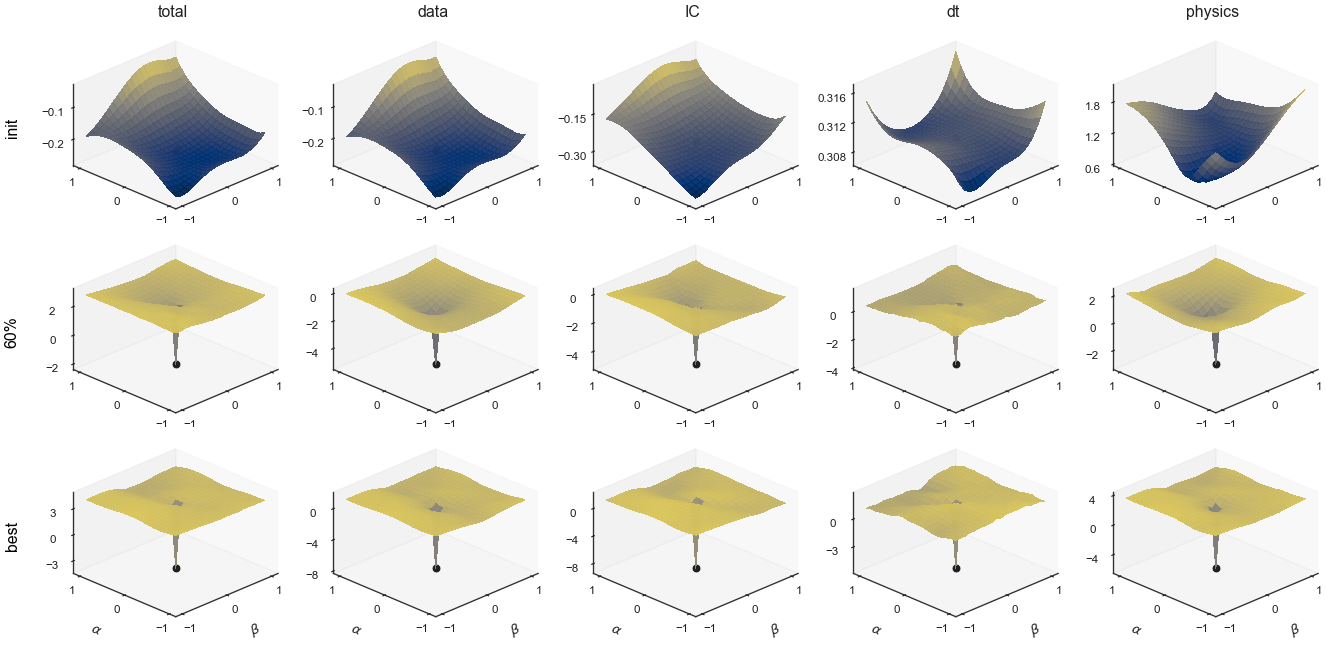

[]

In [17]:
dn_checkpoints = ["init", "epoch_060pct", "best"]
dn_losses = ["total", "data", "ic", "dt", "physics"]
dn_component_landscapes = {}
for checkpoint in dn_checkpoints:
    group = "sm6_evolution_init_s02" if checkpoint == "init" else "sm6_evolution_existing_s02"
    dn_component_landscapes[checkpoint] = load_landscape_dir(
        landscape_path(group, "SM6", "dn_adam3000_ssbroyden2000", checkpoint)
    )

# Per-panel colour scales keep the local landscape geometry visible. Absolute
# component magnitudes are still readable from the z-axis ticks in each panel.
dn_component_norms = {
    (checkpoint, loss): _panel_norm(dn_component_landscapes[checkpoint], loss)
    for checkpoint in dn_checkpoints
    for loss in dn_losses
}

fig = plt.figure(figsize=(11.3, 5.85), constrained_layout=False)
grid = fig.add_gridspec(
    len(dn_checkpoints),
    len(dn_losses),
    wspace=0.02,
    hspace=-0.06,
)
axes_grid = []
for row_idx, checkpoint in enumerate(dn_checkpoints):
    row_axes = []
    for col_idx, loss in enumerate(dn_losses):
        ax = fig.add_subplot(grid[row_idx, col_idx], projection="3d")
        _plot_surface_panel(
            ax,
            dn_component_landscapes[checkpoint],
            loss,
            norm=dn_component_norms[(checkpoint, loss)],
            title=LOSS_LABEL[loss] if row_idx == 0 else "",
            cmap=MODEL_ORDER_3D_CMAP,
            show_axis_labels=row_idx == len(dn_checkpoints) - 1,
        )
        ax.tick_params(axis="both", which="major", labelsize=7.0, pad=-3)
        ax.zaxis.set_tick_params(labelsize=7.0, pad=-1)
        ax.xaxis.label.set_size(8.0)
        ax.yaxis.label.set_size(8.0)
        ax.title.set_size(9.5)
        if col_idx == 0:
            ax.text2D(
                -0.24,
                0.5,
                CHECKPOINT_LABEL[checkpoint],
                transform=ax.transAxes,
                rotation=90,
                ha="center",
                va="center",
                fontsize=9.5,
            )
        row_axes.append(ax)
    axes_grid.append(row_axes)

fig.subplots_adjust(left=0.035, right=0.99, top=0.93, bottom=0.04)
save_landscape_figure(fig, "landscape_3d_sm6_dn_component_evolution")